# Data Science en Smart Grids: Ciclo de Vida Completo del Consumo Eléctrico Residencial
### Austin 2018 · Desde la adquisición cruda hasta la arquitectura predictiva

Este notebook presenta una **arquitectura metodológica completa** para el tratamiento de telemetría de medidores inteligentes. El documento transita desde las bases operativas de ingestión y control de calidad (ETL), pasa por el descubrimiento profundo de patrones térmicos y humanos (EDA), y diseña la estrategia matemática y operativa para futuras puestas en producción (MLOps).

> **Idea central:** `grid` se interpreta como **intercambio neto con la red**, no como consumo bruto del hogar. Por eso los valores negativos son información vital que representa inyección de energía solar hacia la red pública.

### Objetivo Integral del Proyecto
Construir una base analítica robusta, auditable y escalable a nivel ciudad, capaz de soportar modelos predictivos avanzados que anticipen picos de estrés en la infraestructura eléctrica. Este trabajo derriba la barrera técnica principal que suele hacer fracasar los modelos predictivos industriales: la suposición ingenua de que los datos de sensores crudos vienen limpios.

### Alcance del Documento
El notebook documenta y enmarca el flujo analítico completo **End-to-End**:
1. Fases 0 a 2: Contexto de Negocio, Ingesta y Data Quality.
2. Fases 3 y 4: Transformación (ETL) y Análisis Exploratorio (EDA).
3. Fases 5 y 6: Ingeniería de Características (Feature Engineering) y Modelado.
4. Fases 7 y 8: Backtesting Riguroso y Despliegue MLOps.

### Flujo Metodológico
**Negocio → Ingesta → Calidad → Estructuración (ETL) → EDA → Diseño Predictivo → Backtesting → Producción (MLOps)**

**Convención de presentación:** Todas las salidas tabulares generadas por el código incluyen una primera fila llamada **Descripción** para facilitar la lectura documental, mientras que el motor analítico mantiene intactos los tipos de datos originales subyacentes.


# 0. Contexto Estratégico y Definición del Problema

Todo esfuerzo de ingeniería de datos y análisis exploratorio carece de sentido sin un norte claro de negocio. Antes de sumergirnos en la limpieza técnica (ETL) y el descubrimiento estadístico (EDA), es vital definir qué intentamos resolver con las mediciones eléctricas de Austin y cómo llegamos a esta información.

### El Problema a Resolver
La gestión de redes eléctricas inteligentes (smart grids) enfrenta un desafío operativo enorme: la volatilidad extrema de la demanda residencial, especialmente en zonas con climas rigurosos o alta penetración de energía solar. Nuestro objetivo analítico se centra en **caracterizar y sentar las bases para predecir los picos de demanda neta a nivel de hogar individual**.

Entender con precisión cuándo y por qué una vivienda se convierte en un estrés para el sistema (o en un soporte temporal, si inyecta energía) permite a las empresas distribuidoras:
- Diseñar arquitecturas de tarifas dinámicas más justas y eficientes.
- Dimensionar la capacidad de tolerancia de la red ante eventos climáticos severos (como olas de calor sostenidas).
- Diseñar campañas de incentivos altamente personalizadas para desplazar cargas energéticas fuera de los horarios críticos.

### La Naturaleza de los Datos
Para abordar este reto, partimos de un esquema de recolección basado en medidores inteligentes de alta frecuencia, cubriendo el año 2018. Esto nos provee dos frentes de información que necesitamos integrar:
1.  **La Serie Temporal:** Registros exhaustivos tomados cada 15 minutos, detallando no solo el consumo global, sino el comportamiento de circuitos críticos (climatización, bombeo, generación solar).
2.  **El Contexto Estructural:** Metadatos estáticos asociados a las viviendas (antigüedad, metros cuadrados, características del sistema fotovoltaico).

La fricción principal reside en que estos datos crudos son ruidosos, presentan vacíos operacionales y son estructuralmente heterogéneos. Precisamente para salvar la distancia entre este material bruto y la necesidad de negocio descrita, el presente notebook ejecuta el proceso fundacional de estructuración, control de calidad y entendimiento profundo.


---

# Fases 1 y 2: Adquisición y Control de Calidad (Data Ingestion & Quality)

Antes de cualquier análisis estadístico, los datos deben ser rescatados de su origen y auditados. La realidad de los sistemas IoT (como los medidores inteligentes) es que son propensos a fallas de transmisión, cortes de energía y errores de firmware.

### Ingesta (El Contrato de Datos)
El primer paso metodológico es establecer un 'Contrato de Datos'. Esto significa documentar explícitamente qué esperamos recibir frente a lo que realmente tenemos:
*   **Volumen y Cobertura:** ¿Cuántos hogares estamos monitoreando? ¿Es una muestra estadísticamente representativa de la red?
*   **Granularidad Temporal:** Se espera una lectura cada 15 minutos (96 lecturas diarias por hogar). Cualquier desviación o hueco implica pérdida de información térmica crítica.

### Control de Calidad (Data Quality)
Asumir que los datos tabulares vienen limpios es el error más costoso en Data Science. En esta fase, implementamos controles estrictos:
*   **Detección de Nulos Semánticos:** Un valor nulo en consumo eléctrico no siempre significa 'cero consumo'; puede significar 'el medidor perdió conexión a internet'. Imputar un cero ciegamente arruinaría la integridad del análisis temporal.
*   **Validación Física:** ¿Tiene sentido un valor negativo en la red (`grid`)? En una casa tradicional, sería un error de hardware. En un hogar con paneles solares, un valor negativo es información pura: significa inyección de excedentes a la red pública.


---

# Fase 3: Transformación y Estructuración (El núcleo del ETL)

Con los datos auditados, el proceso de ETL (Extract, Transform, Load) se encarga de moldear la información masiva para que sea consumible algorítmicamente. En el contexto de *Smart Grids*, esto requiere manejar volumetrías pesadas y alinear múltiples dimensiones temporales.

### Arquitectura de Procesamiento
Para procesar millones de registros granulares de telemetría, cargar todo en memoria (ej. con Pandas) es ineficiente y no escala a nivel ciudad.
*   **Uso de Motores Analíticos:** Se emplean bases de datos o motores OLAP (como DuckDB o Spark) que permiten consultar archivos crudos mediante SQL optimizado, filtrando y agregando datos antes de llevarlos a la memoria RAM para visualización.

### Alineación Temporal y Fusión
El tiempo es la dimensión más volátil en IoT.
*   **Zonas Horarias Relativas:** Las bases de datos operan en UTC para garantizar una continuidad matemática perfecta, esquivando los cambios de horario de verano. Sin embargo, para extraer el comportamiento humano (ej. encendido de HVAC a las 18:00), los timestamps deben proyectarse dinámicamente a la hora local (`America/Chicago`).
*   **Fusión (Joins):** Es el momento de cruzar la serie de alta frecuencia con los metadatos. Adherir la antigüedad o el tamaño de la casa a la lectura de consumo permite crear un *Data Mart* enriquecido.


---

# Fase 4: Análisis Exploratorio de Datos (EDA)

El EDA no es un simple reporte de métricas; es un proceso forense para interrogar al dataset y validar las hipótesis de negocio. Es el puente indispensable entre la ingeniería de datos rígida y los modelos predictivos estadísticos.

### Descubrimiento de Patrones Físicos y Humanos
En lugar de entrenar modelos a ciegas, el EDA busca revelar la estructura subyacente de la electricidad:
*   **Estacionalidad:** Analizar cómo fluctúa la carga durante el día (ej. la famosa *duck curve* solar) y cómo el verano dispara exponencialmente los picos frente a los meses de invierno.
*   **Heterogeneidad de la Muestra:** El 'hogar promedio' no existe. Algunos consumen cinco veces más que otros por ineficiencias térmicas. Usar un umbral global absoluto es engañoso; el EDA debe demostrar que cada vivienda necesita su propio marco de normalidad (percentiles locales).

### Análisis de Eventos de Riesgo (Anomalías y Picos)
Para la operadora de red, el promedio de consumo es operativamente inútil; lo que destruye infraestructura son los picos sostenidos.
*   **Persistencia:** El EDA debe identificar no solo cuándo ocurre un pico de estrés (P95 o P99), sino cuánto dura. Un pico de 15 minutos es ruido electromagnético; un pico que persiste por 4 horas consecutivas en un vecindario es un evento crítico que nuestros modelos futuros deberán aprender a prevenir.

*(Nota metodológica: Las celdas de código Python/SQL que conforman el cuerpo principal de este notebook ejecutan, en la práctica y de forma secuencial, estas cuatro primeras fases fundacionales).* 
---


# 1. Configuración del entorno

### Problema y objetivo
El dataset temporal es grande y combina variables eléctricas, timestamps con zona horaria y metadata estática. Necesitamos un entorno único, reproducible y eficiente antes de comenzar el análisis.

**Preguntas que resolvemos**
- ¿Dónde están los archivos de entrada dentro de Kaggle?
- ¿Qué motor usamos para evitar cargar innecesariamente toda la tabla temporal en pandas?
- ¿Cómo estandarizamos la presentación de tablas y gráficos?

La celda siguiente concentra **todos los imports, dependencias, configuración visual y funciones auxiliares** del notebook. Las siguientes secciones no vuelven a importar librerías.

*   **Estabilidad y Voltaje:** `leg1v`, `leg2v` y un promedio de ambas (`avg_voltage`). Son los indicadores directos de la estabilidad de la infraestructura.
*   **Climatización (Picos):** `air1`, `air2`, `furnace1` (y su suma `hvac_demand`). Fundamentales para explicar el origen de los picos de demanda en verano.

In [19]:
# [S01-C01] Configuración, dependencias y funciones auxiliares
# Rol: Lead Analyst / Kaggle ETL Engineer
# Estado: REALIZADO

from pathlib import Path
import os
import math
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from IPython.display import display

# ---------------------------------------------------------------------
# Configuración global
# ---------------------------------------------------------------------
LOCAL_TZ = "America/Chicago"
EXPECTED_FREQ_MIN = 15
EXPECTED_HOMES = 25

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 180)

plt.rcParams.update({
    "figure.figsize": (10, 4.8),
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
    "figure.dpi": 110,
})

warnings.filterwarnings("ignore", category=FutureWarning)

def find_input_file(filename):
    """Busca el archivo en Kaggle, /mnt/data y el directorio actual."""
    roots = [Path("/kaggle/input"), Path("/mnt/data"), Path.cwd()]
    for root in roots:
        if not root.exists():
            continue
        exact = root / filename
        if exact.exists():
            return exact
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(
        f"No se encontró '{filename}'. Verificar que el dataset esté adjunto al notebook."
    )

def sql_path(path):
    """Escapa un path para utilizarlo dentro de SQL de DuckDB."""
    return str(path).replace("'", "''")

def qident(name):
    """Escapa un identificador SQL."""
    return '"' + str(name).replace('"', '""') + '"'

COLUMN_DESCRIPTIONS = {
    "variable": "Nombre de la variable analizada.",
    "metric": "Nombre de la métrica o control.",
    "metrica": "Nombre de la métrica o control.",
    "value": "Valor observado de la métrica.",
    "valor": "Valor observado de la métrica.",
    "dataid": "Identificador único del hogar.",
    "n_rows": "Cantidad de filas o registros.",
    "n_total": "Cantidad total de registros considerados.",
    "n_homes": "Cantidad de hogares distintos.",
    "n_hogares": "Cantidad de hogares distintos.",
    "n_non_null": "Cantidad de valores observados no nulos.",
    "n_null": "Cantidad de valores nulos.",
    "pct_null": "Porcentaje de valores nulos.",
    "pct_non_null": "Porcentaje de valores no nulos.",
    "n_unique_non_null": "Cantidad de valores únicos o diferentes entre los no nulos.",
    "status": "Resultado o estado del control.",
    "check": "Validación de integridad ejecutada.",
    "detail": "Detalle técnico del resultado.",
    "threshold": "Umbral exploratorio utilizado.",
    "threshold_value": "Valor numérico del umbral.",
    "n_events": "Cantidad de eventos consecutivos.",
    "duration_minutes": "Duración del evento en minutos.",
    "coverage_ratio": "Proporción de hogares con grid válido respecto del total esperado.",
    "row_coverage_ratio": "Proporción de hogares con fila presente respecto del total esperado.",
    "n_grid_valid": "Cantidad de observaciones válidas de grid.",
    "n_homes_rows": "Cantidad de hogares con fila presente en el timestamp.",
    "mean_grid": "Media de grid para el conjunto indicado.",
    "median_grid": "Mediana de grid para el conjunto indicado.",
    "P95_grid": "Percentil 95 de grid.",
    "P99_grid": "Percentil 99 de grid.",
    "pct_grid_negative": "Porcentaje de observaciones de grid menores que cero.",
}

def _auto_description(column):
    if column in COLUMN_DESCRIPTIONS:
        return COLUMN_DESCRIPTIONS[column]
    if column.startswith("n_"):
        return "Cantidad asociada a " + column[2:].replace("_", " ") + "."
    if column.startswith("pct_"):
        return "Porcentaje asociado a " + column[4:].replace("_", " ") + "."
    if column.startswith("P95") or "_P95" in column:
        return "Percentil 95 o métrica asociada al percentil 95."
    if column.startswith("P99") or "_P99" in column:
        return "Percentil 99 o métrica asociada al percentil 99."
    if column.endswith("_ratio"):
        return "Proporción asociada a " + column[:-6].replace("_", " ") + "."
    if "timestamp" in column or column.startswith("ts_") or "_ts_" in column:
        return "Marca temporal asociada al registro."
    return "Campo: " + column.replace("_", " ") + "."

def _format_for_display(value, precision=3):
    if pd.isna(value):
        return "—"
    if isinstance(value, (bool, np.bool_)):
        return "Sí" if value else "No"
    if isinstance(value, (pd.Timestamp, np.datetime64)):
        return str(pd.Timestamp(value))
    if isinstance(value, (float, np.floating)):
        return f"{float(value):,.{precision}f}"
    if isinstance(value, (int, np.integer)):
        return f"{int(value):,}"
    return str(value)

def show_table(dataframe, title, descriptions=None, max_rows=15, precision=3):
    """
    Muestra una copia de presentación.
    La primera fila documenta el significado de cada columna.
    El DataFrame original no se modifica.
    """
    descriptions = descriptions or {}
    view = dataframe.copy()
    if max_rows is not None and len(view) > max_rows:
        view = view.head(max_rows)

    formatted = view.copy()
    for column in formatted.columns:
        formatted[column] = formatted[column].map(
            lambda x: _format_for_display(x, precision)
        )

    description_row = {
        column: descriptions.get(column, _auto_description(column))
        for column in formatted.columns
    }

    presentation = pd.concat(
        [pd.DataFrame([description_row]), formatted],
        ignore_index=True,
    )
    presentation.index = ["Descripción"] + [
        str(i) for i in range(1, len(presentation))
    ]

    styler = (
        presentation.style
        .set_caption(title)
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("font-size", "14px"),
                    ("font-weight", "600"),
                    ("text-align", "left"),
                    ("padding", "8px 0"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("white-space", "normal"),
                ],
            },
        ])
        .apply(
            lambda row: [
                (
                    "background-color: #eef4fb; "
                    "font-weight: 600; "
                    "white-space: normal;"
                )
                if row.name == "Descripción"
                else ""
                for _ in row
            ],
            axis=1,
        )
    )
    display(styler)

con = duckdb.connect(database=":memory:")
con.execute("SET TimeZone='UTC'")

### Resultado de la sección
El notebook queda configurado alrededor de una **única conexión DuckDB** para el procesamiento pesado y pandas/matplotlib para tablas pequeñas y visualización. La zona horaria de referencia para interpretación civil es `America/Chicago`, mientras que la continuidad temporal se analizará en UTC.

La función `show_table()` no altera los datos: crea una copia de presentación donde la primera fila explica cada columna, haciendo que las salidas sean más fáciles de leer y exponer.

# 2. Fuentes de datos y contrato de entrada

### Problema y objetivo
Antes de transformar datos necesitamos conocer exactamente qué recibimos y establecer un contrato de entrada. Esto evita construir el ETL sobre supuestos incorrectos.

**Preguntas**
- ¿Cuántas filas, columnas, hogares y timestamps contiene cada fuente?
- ¿La metadata incluye información adicional que no corresponde a hogares?
- ¿Cuál es el período real cubierto por las mediciones?

La tabla temporal se consulta directamente desde CSV con DuckDB; la metadata, mucho más pequeña, se carga en pandas.

In [20]:
# [S02-C01] Localización, carga raw y contrato de entrada
# Rol: Data Quality Analyst / Kaggle ETL Engineer
# Estado: REALIZADO

METADATA_PATH = find_input_file("metadata.csv")
TEMPORAL_PATH = find_input_file("15minute_data_austin.csv")

metadata_raw = pd.read_csv(METADATA_PATH, low_memory=False)

con.execute(f"""
CREATE OR REPLACE VIEW raw_measurements AS
SELECT *
FROM read_csv_auto(
    '{sql_path(TEMPORAL_PATH)}',
    HEADER = TRUE,
    SAMPLE_SIZE = -1
)
""")

schema_raw = con.execute("DESCRIBE raw_measurements").df()

temporal_contract = con.execute("""
SELECT
    COUNT(*) AS n_rows,
    COUNT(DISTINCT dataid) AS n_homes,
    COUNT(DISTINCT local_15min) AS n_distinct_timestamps,
    MIN(local_15min) AS first_timestamp_source,
    MAX(local_15min) AS last_timestamp_source
FROM raw_measurements
""").df()

source_inventory = pd.DataFrame([
    {
        "source": "metadata.csv",
        "rows": len(metadata_raw),
        "columns": len(metadata_raw.columns),
        "role": "Metadata de hogares; la primera fila contiene definiciones.",
    },
    {
        "source": "15minute_data_austin.csv",
        "rows": int(temporal_contract.loc[0, "n_rows"]),
        "columns": len(schema_raw),
        "role": "Mediciones eléctricas residenciales con frecuencia nominal de 15 minutos.",
    },
])

show_table(
    source_inventory,
    "Inventario de fuentes",
    descriptions={
        "source": "Archivo de entrada.",
        "rows": "Cantidad de filas físicas del archivo.",
        "columns": "Cantidad de columnas.",
        "role": "Función del archivo dentro del proyecto.",
    },
    max_rows=None,
)

show_table(
    temporal_contract,
    "Contrato del dataset temporal",
    descriptions={
        "first_timestamp_source": "Primer timestamp observado en la fuente.",
        "last_timestamp_source": "Último timestamp observado en la fuente.",
        "n_distinct_timestamps": "Cantidad de timestamps distintos presentes en la fuente.",
    },
    max_rows=None,
)

,source,rows,columns,role
Descripción,Archivo de entrada.,Cantidad de filas físicas del archivo.,Cantidad de columnas.,Función del archivo dentro del proyecto.
1,metadata.csv,"2,036",130,Metadata de hogares; la primera fila contiene definiciones.
2,15minute_data_austin.csv,"873,286",79,Mediciones eléctricas residenciales con frecuencia nominal de 15 minutos.


,n_rows,n_homes,n_distinct_timestamps,first_timestamp_source,last_timestamp_source
Descripción,Cantidad de filas o registros.,Cantidad de hogares distintos.,Cantidad de timestamps distintos presentes en la fuente.,Primer timestamp observado en la fuente.,Último timestamp observado en la fuente.
1,"873,286",25,"35,036",2018-01-01 06:00:00+00:00,2019-01-01 05:45:00+00:00


### Hallazgos
Las fuentes quedan claramente separadas: `metadata.csv` contiene **2.036 filas y 130 columnas**, pero su primera fila es un diccionario embebido; por tanto existen **2.035 hogares reales de metadata**. La serie temporal contiene **873.286 filas, 79 columnas, 25 hogares y 35.036 timestamps observados**.

El período corresponde a todo 2018 en hora local de Austin. Esta separación entre una fuente estática amplia y un subconjunto temporal de 25 hogares condiciona el resto del análisis: **no toda la metadata pertenece al universo temporal utilizado**.

# 3. Calidad y preparación de metadata

### Problema y objetivo
La metadata mezcla valores numéricos, fechas, porcentajes y una primera fila que actúa como diccionario. Si se usa sin separar y tipar, puede contaminar joins y análisis posteriores.

**Preguntas**
- ¿Qué parte del archivo son hogares reales?
- ¿Los 25 hogares temporales encuentran correspondencia en metadata?
- ¿Qué atributos tienen información suficiente y qué inconsistencias de calidad existen?

La estrategia es conservadora: se separa la fila-diccionario, se convierten sólo familias de tipos identificables y no se elimina información por reglas arbitrarias.

In [21]:
# [S03-C01] Limpieza controlada y perfil de metadata
# Rol: Data Quality Analyst
# Estado: REALIZADO

metadata_dictionary = metadata_raw.iloc[0].copy()
df_meta = metadata_raw.iloc[1:].copy().reset_index(drop=True)

numeric_cols = [
    "dataid",
    "house_construction_year",
    "total_square_footage",
    "first_floor_square_footage",
    "second_floor_square_footage",
    "third_floor_square_footage",
    "half_floor_square_footage",
    "lower_level_square_footage",
    "total_amount_of_pv",
    "amount_of_south_facing_pv",
    "amount_of_west_facing_pv",
    "amount_of_east_facing_pv",
    "number_of_nests",
]
integer_cols = {"dataid", "house_construction_year", "number_of_nests"}

availability_cols = [
    column
    for column in df_meta.columns
    if column.endswith("_data_availability")
]

datetime_cols = [
    column
    for column in df_meta.columns
    if column.endswith("_min_time")
    or column.endswith("_max_time")
]

conversion_rows = []

for column in numeric_cols:
    if column not in df_meta.columns:
        continue
    original = df_meta[column]
    parsed = pd.to_numeric(original, errors="coerce")
    lost = int((original.notna() & parsed.isna()).sum())
    if lost == 0:
        if column in integer_cols:
            parsed = parsed.astype("Int64")
        df_meta[column] = parsed
    conversion_rows.append({
        "variable": column,
        "conversion": "numeric",
        "values_lost": lost,
    })

for column in availability_cols:
    original = df_meta[column]
    parsed = pd.to_numeric(
        original.astype("string").str.strip().str.rstrip("%"),
        errors="coerce",
    )
    lost = int((original.notna() & parsed.isna()).sum())
    if lost == 0:
        df_meta[column] = parsed
    conversion_rows.append({
        "variable": column,
        "conversion": "percentage_0_100",
        "values_lost": lost,
    })

for column in datetime_cols:
    original = df_meta[column]
    try:
        parsed = pd.to_datetime(
            original,
            errors="coerce",
            utc=True,
            format="mixed",
        )
    except TypeError:
        parsed = pd.to_datetime(
            original,
            errors="coerce",
            utc=True,
        )
    lost = int((original.notna() & parsed.isna()).sum())
    if lost == 0:
        df_meta[column] = parsed
    conversion_rows.append({
        "variable": column,
        "conversion": "datetime_utc",
        "values_lost": lost,
    })

metadata_type_report = pd.DataFrame(conversion_rows)

temporal_ids = set(
    con.execute(
        "SELECT DISTINCT CAST(dataid AS BIGINT) AS dataid FROM raw_measurements"
    ).df()["dataid"]
)

meta_temporal = (
    df_meta[df_meta["dataid"].isin(temporal_ids)]
    .copy()
)

selected_metadata = [
    column
    for column in [
        "building_type",
        "house_construction_year",
        "total_square_footage",
        "pv",
        "solar",
        "total_amount_of_pv",
        "pv_panel_direction",
    ]
    if column in meta_temporal.columns
]

metadata_availability = pd.DataFrame([
    {
        "variable": column,
        "n_homes": len(meta_temporal),
        "n_non_null": int(meta_temporal[column].notna().sum()),
        "pct_non_null": 100.0 * meta_temporal[column].notna().mean(),
        "n_unique_non_null": int(meta_temporal[column].dropna().nunique()),
    }
    for column in selected_metadata
])

availability_out_of_range = sum(
    int((df_meta[column] > 100).sum())
    for column in availability_cols
)

metadata_quality_summary = pd.DataFrame([
    {"metrica": "hogares_metadata_reales", "valor": len(df_meta)},
    {"metrica": "dataid_duplicados", "valor": int(df_meta["dataid"].duplicated().sum())},
    {"metrica": "hogares_temporales", "valor": len(temporal_ids)},
    {"metrica": "hogares_temporales_con_metadata", "valor": len(meta_temporal)},
    {"metrica": "valores_availability_mayores_100", "valor": availability_out_of_range},
])

show_table(
    metadata_quality_summary,
    "Controles principales de metadata",
    max_rows=None,
)

show_table(
    metadata_availability,
    "Disponibilidad de atributos en los 25 hogares temporales",
    max_rows=None,
)

,metrica,valor
Descripción,Nombre de la métrica o control.,Valor observado de la métrica.
1,hogares_metadata_reales,"2,035"
2,dataid_duplicados,0
3,hogares_temporales,25
4,hogares_temporales_con_metadata,25
5,valores_availability_mayores_100,26


,variable,n_homes,n_non_null,pct_non_null,n_unique_non_null
Descripción,Nombre de la variable analizada.,Cantidad de hogares distintos.,Cantidad de valores observados no nulos.,Porcentaje de valores no nulos.,Cantidad de valores únicos o diferentes entre los no nulos.
1,building_type,25,25,100.000,2
2,house_construction_year,25,25,100.000,9
3,total_square_footage,25,25,100.000,17
4,pv,25,19,76.000,1
5,solar,25,19,76.000,1
6,total_amount_of_pv,25,18,72.000,15
7,pv_panel_direction,25,16,64.000,3


### Hallazgos
La fila-diccionario se separa sin perderla como referencia documental y quedan **2.035 hogares reales**. Los **25 `dataid` del dataset temporal tienen metadata asociada**, por lo que el join posterior es viable.

Los atributos estructurales más útiles para este subconjunto —año de construcción y superficie— están completos; `pv`/`solar` de metadata están informados en 19 de 25 hogares. También se detectan **26 valores de campos `*_data_availability` superiores a 100**, por lo que esos porcentajes no deben asumirse automáticamente como métricas perfectas de calidad. La decisión es conservarlos y documentar la inconsistencia, no corregirlos sin evidencia.

# 4. Calidad del dataset de mediciones

### Problema y objetivo
La serie temporal tiene 77 variables de medición, muchas de ellas específicas de circuitos domésticos. Antes de convertir o filtrar debemos saber qué columnas contienen información, qué faltantes son relevantes y si las claves son únicas.

**Preguntas**
- ¿Existen duplicados por `dataid × timestamp`?
- ¿Cuántas variables están completamente vacías?
- ¿Cuánto faltante presentan `grid` y `solar`?
- ¿Los valores negativos de `grid` son un problema de calidad?

El análisis distingue entre **dato ausente** y **valor observado negativo**. Un `grid < 0` se conserva como observación válida.

In [22]:
# [S04-C01] Perfil de calidad de mediciones
# Rol: Data Quality Analyst
# Estado: REALIZADO

raw_columns = schema_raw["column_name"].tolist()
measurement_cols = [
    column
    for column in raw_columns
    if column not in {"dataid", "local_15min"}
]

# ---------------------------------------------------------------------
# Auditoría de tipado, faltantes y columnas sin información
# ---------------------------------------------------------------------
quality_exprs = []

for i, column in enumerate(measurement_cols):
    q = qident(column)
    quality_exprs.extend([
        f"COUNT({q}) AS raw_nn_{i}",
        f"COUNT(TRY_CAST({q} AS DOUBLE)) AS num_nn_{i}",
        f"MIN(TRY_CAST({q} AS DOUBLE)) AS min_{i}",
        f"MAX(TRY_CAST({q} AS DOUBLE)) AS max_{i}",
    ])

quality_wide = con.execute(f"""
SELECT
    COUNT(*) AS n_rows,
    {", ".join(quality_exprs)}
FROM raw_measurements
""").df()

n_rows_raw = int(quality_wide.loc[0, "n_rows"])
quality_rows = []

for i, column in enumerate(measurement_cols):
    raw_nn = int(quality_wide.loc[0, f"raw_nn_{i}"])
    numeric_nn = int(quality_wide.loc[0, f"num_nn_{i}"])
    min_value = quality_wide.loc[0, f"min_{i}"]
    max_value = quality_wide.loc[0, f"max_{i}"]

    quality_rows.append({
        "variable": column,
        "n_not_null": raw_nn,
        "n_null": n_rows_raw - raw_nn,
        "pct_null": 100.0 * (n_rows_raw - raw_nn) / n_rows_raw,
        "parse_failures": raw_nn - numeric_nn,
        "is_fully_null": raw_nn == 0,
        "is_constant_non_null": (
            numeric_nn > 0
            and pd.notna(min_value)
            and pd.notna(max_value)
            and float(min_value) == float(max_value)
        ),
    })

measurement_column_quality = (
    pd.DataFrame(quality_rows)
    .sort_values(
        ["pct_null", "variable"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

duplicate_key_groups = int(
    con.execute("""
        SELECT COUNT(*)
        FROM (
            SELECT dataid, local_15min
            FROM raw_measurements
            GROUP BY dataid, local_15min
            HAVING COUNT(*) > 1
        )
    """).fetchone()[0]
)

core_quality = con.execute("""
SELECT
    COUNT(*) AS n_rows,
    COUNT(DISTINCT dataid) AS n_homes,
    COUNT(DISTINCT local_15min) AS n_distinct_timestamps,

    COUNT(*) - COUNT(grid) AS grid_null,
    100.0 * (COUNT(*) - COUNT(grid)) / COUNT(*) AS grid_pct_null,

    COUNT(*) FILTER (WHERE grid < 0) AS grid_negative,
    100.0 * COUNT(*) FILTER (WHERE grid < 0) / COUNT(grid)
        AS grid_pct_negative_observed,

    COUNT(*) - COUNT(solar) AS solar_null,
    100.0 * (COUNT(*) - COUNT(solar)) / COUNT(*) AS solar_pct_null,

    COUNT(*) - COUNT(solar2) AS solar2_null,
    100.0 * (COUNT(*) - COUNT(solar2)) / COUNT(*) AS solar2_pct_null

FROM raw_measurements
""").df()

measurement_quality_summary = pd.DataFrame([
    {"metrica": "variables_de_medicion", "valor": len(measurement_cols)},
    {
        "metrica": "variables_completamente_nulas",
        "valor": int(measurement_column_quality["is_fully_null"].sum()),
    },
    {
        "metrica": "fallos_conversion_numerica",
        "valor": int(measurement_column_quality["parse_failures"].sum()),
    },
    {"metrica": "grupos_clave_duplicada", "valor": duplicate_key_groups},
])

# ---------------------------------------------------------------------
# Disponibilidad solar frente a metadata
# ---------------------------------------------------------------------
solar_by_home = con.execute("""
SELECT
    dataid,
    COUNT(*) AS n_rows,
    COUNT(solar) AS solar_not_null,
    COUNT(*) - COUNT(solar) AS solar_null,
    100.0 * (COUNT(*) - COUNT(solar)) / COUNT(*) AS solar_pct_null
FROM raw_measurements
GROUP BY dataid
ORDER BY dataid
""").df()

meta_pv = meta_temporal[
    [
        column
        for column in ["dataid", "pv", "solar"]
        if column in meta_temporal.columns
    ]
].copy()

solar_vs_metadata = solar_by_home.merge(
    meta_pv,
    on="dataid",
    how="left",
    validate="one_to_one",
)

def _yes(series):
    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .eq("yes")
        .fillna(False)
    )

pv_declared = pd.Series(False, index=solar_vs_metadata.index)

for column in ["pv", "solar"]:
    if column in solar_vs_metadata.columns:
        pv_declared = pv_declared | _yes(
            solar_vs_metadata[column]
        )

solar_vs_metadata["pv_declared"] = pv_declared

conditions = [
    (~pv_declared) & (solar_vs_metadata["solar_not_null"] == 0),
    (pv_declared) & (solar_vs_metadata["solar_not_null"] == 0),
    (pv_declared) & (solar_vs_metadata["solar_null"] > 0),
    (pv_declared) & (solar_vs_metadata["solar_null"] == 0),
    (~pv_declared) & (solar_vs_metadata["solar_not_null"] > 0),
]

labels = [
    "sin_PV_declarado_y_sin_lecturas",
    "PV_declarado_sin_lecturas",
    "PV_declarado_con_faltantes",
    "PV_declarado_cobertura_completa",
    "lecturas_solar_sin_PV_declarado",
]

solar_vs_metadata["classification"] = np.select(
    conditions,
    labels,
    default="caso_ambiguo",
)

solar_metadata_summary = (
    solar_vs_metadata["classification"]
    .value_counts()
    .rename_axis("classification")
    .reset_index(name="n_homes")
)

show_table(
    measurement_quality_summary,
    "Resumen de calidad de variables de medición",
    max_rows=None,
)

show_table(
    core_quality,
    "Calidad de grid y solar",
    descriptions={
        "grid_null": "Cantidad de filas con grid nulo.",
        "grid_pct_null": "Porcentaje de filas con grid nulo.",
        "grid_negative": "Cantidad de valores observados de grid menores que cero.",
        "grid_pct_negative_observed": "Porcentaje de grid negativo sobre observaciones válidas.",
        "solar_null": "Cantidad de filas con solar nulo.",
        "solar_pct_null": "Porcentaje de filas con solar nulo.",
        "solar2_null": "Cantidad de filas con solar2 nulo.",
        "solar2_pct_null": "Porcentaje de filas con solar2 nulo.",
    },
    max_rows=None,
)

show_table(
    solar_metadata_summary,
    "Disponibilidad de solar frente a PV declarado en metadata",
    descriptions={
        "classification": "Patrón descriptivo de disponibilidad solar y declaración de PV.",
    },
    max_rows=None,
)

,metrica,valor
Descripción,Nombre de la métrica o control.,Valor observado de la métrica.
1,variables_de_medicion,77
2,variables_completamente_nulas,31
3,fallos_conversion_numerica,0
4,grupos_clave_duplicada,0


,n_rows,n_homes,n_distinct_timestamps,grid_null,grid_pct_null,grid_negative,grid_pct_negative_observed,solar_null,solar_pct_null,solar2_null,solar2_pct_null
Descripción,Cantidad de filas o registros.,Cantidad de hogares distintos.,Cantidad asociada a distinct timestamps.,Cantidad de filas con grid nulo.,Porcentaje de filas con grid nulo.,Cantidad de valores observados de grid menores que cero.,Porcentaje de grid negativo sobre observaciones válidas.,Cantidad de filas con solar nulo.,Porcentaje de filas con solar nulo.,Cantidad de filas con solar2 nulo.,Porcentaje de filas con solar2 nulo.
1,"873,286",25,"35,036","5,190",0.594,"148,348",17.089,"213,297",24.425,"873,286",100.000


,classification,n_homes
Descripción,Patrón descriptivo de disponibilidad solar y declaración de PV.,Cantidad de hogares distintos.
1,PV_declarado_con_faltantes,11
2,PV_declarado_cobertura_completa,8
3,sin_PV_declarado_y_sin_lecturas,5
4,lecturas_solar_sin_PV_declarado,1


### Hallazgos
La clave lógica `dataid × local_15min` no presenta duplicados y las 77 columnas de medición pueden auditarse sin pérdida de conversión numérica. **31 de las 77 variables están completamente vacías** en este subconjunto, incluida `solar2`.

`grid` tiene **5.190 nulos (0,594%)** y **148.348 valores negativos**, equivalentes al **17,09% de las observaciones válidas**. Los negativos no se corrigen: son coherentes con la semántica de intercambio neto. `solar` tiene **213.297 nulos (24,42%)** y su missingness depende fuertemente del hogar y de la disponibilidad del canal; incluso existe un hogar con lecturas solares sin PV declarado en metadata. Esto justifica tratar el faltante solar con cautela y no convertir `NULL` en cero.

# 5. Construcción de la capa analítica

### Problema y objetivo
El raw mezcla tipos y conserva el timestamp con offset. Para analizar patrones horarios y construir targets futuros necesitamos dos relojes con propósitos distintos:

- **`ts_utc`** para continuidad y alineación exacta;
- **`ts_local`** para hora, día y mes de Austin.

**Preguntas**
- ¿Podemos convertir las 77 mediciones a numérico sin perder valores?
- ¿La transformación conserva filas, hogares, claves y faltantes?
- ¿Las variables temporales quedan derivadas del reloj correcto?

La capa raw se mantiene intacta; se crean vistas derivadas y luego un QA formal.

In [23]:
# [S05-C01] Capa analítica, tiempo dual y QA
# Rol: Kaggle ETL Engineer / QA Analyst
# Estado: REALIZADO

parse_failures_total = int(
    measurement_column_quality["parse_failures"].sum()
)

if parse_failures_total != 0:
    raise RuntimeError(
        f"Se detectaron {parse_failures_total} fallos de conversión numérica. "
        "La capa analítica no se construye hasta revisar el origen."
    )

typed_measurements_sql = ",\n    ".join(
    f"TRY_CAST({qident(column)} AS DOUBLE) AS {qident(column)}"
    for column in measurement_cols
)

con.execute(f"""
CREATE OR REPLACE VIEW measurements_staging AS
SELECT
    CAST(dataid AS BIGINT) AS dataid,
    TRY_CAST(local_15min AS TIMESTAMPTZ) AS ts_source,
    {typed_measurements_sql}
FROM raw_measurements
""")

measurements_sql = ",\n    ".join(
    qident(column)
    for column in measurement_cols
)

con.execute(f"""
CREATE OR REPLACE VIEW measurements_analytic AS
SELECT
    dataid,
    ts_source,

    ts_source AT TIME ZONE 'UTC' AS ts_utc,
    ts_source AT TIME ZONE '{LOCAL_TZ}' AS ts_local,

    CAST(ts_source AT TIME ZONE '{LOCAL_TZ}' AS DATE) AS local_date,
    CAST(EXTRACT(YEAR FROM ts_source AT TIME ZONE '{LOCAL_TZ}') AS INTEGER) AS year,
    CAST(EXTRACT(MONTH FROM ts_source AT TIME ZONE '{LOCAL_TZ}') AS INTEGER) AS month,
    CAST(EXTRACT(HOUR FROM ts_source AT TIME ZONE '{LOCAL_TZ}') AS INTEGER) AS hour,
    CAST(EXTRACT(MINUTE FROM ts_source AT TIME ZONE '{LOCAL_TZ}') AS INTEGER) AS minute,
    CAST(date_part('isodow', ts_source AT TIME ZONE '{LOCAL_TZ}') AS INTEGER) AS weekday,
    date_part('isodow', ts_source AT TIME ZONE '{LOCAL_TZ}') IN (6, 7) AS is_weekend,

    {measurements_sql},

    grid IS NULL AS grid_missing,
    solar IS NULL AS solar_missing,
    solar2 IS NULL AS solar2_missing,
    COALESCE(grid < 0, FALSE) AS grid_negative

FROM measurements_staging
""")

analytic_summary = con.execute("""
SELECT
    COUNT(*) AS n_rows,
    COUNT(DISTINCT dataid) AS n_homes,
    COUNT(DISTINCT ts_utc) AS n_distinct_timestamps,
    MIN(ts_utc) AS ts_utc_min,
    MAX(ts_utc) AS ts_utc_max,
    MIN(ts_local) AS ts_local_min,
    MAX(ts_local) AS ts_local_max,
    COUNT(*) FILTER (WHERE grid IS NULL) AS grid_null,
    COUNT(*) FILTER (WHERE solar IS NULL) AS solar_null,
    COUNT(*) FILTER (WHERE solar2 IS NULL) AS solar2_null,
    COUNT(*) FILTER (WHERE grid < 0) AS grid_negative
FROM measurements_analytic
""").df()

analytic_columns = set(
    con.execute("DESCRIBE measurements_analytic").df()["column_name"]
)

qa_checks = []

def add_check(check, passed, detail):
    qa_checks.append({
        "check": check,
        "status": "PASS" if bool(passed) else "FAIL",
        "detail": detail,
    })

raw_key_count = int(
    con.execute("""
        SELECT COUNT(*)
        FROM (
            SELECT DISTINCT dataid, local_15min
            FROM raw_measurements
        )
    """).fetchone()[0]
)

analytic_key_count = int(
    con.execute("""
        SELECT COUNT(*)
        FROM (
            SELECT DISTINCT dataid, ts_source
            FROM measurements_analytic
        )
    """).fetchone()[0]
)

analytic_duplicate_groups = int(
    con.execute("""
        SELECT COUNT(*)
        FROM (
            SELECT dataid, ts_source
            FROM measurements_analytic
            GROUP BY dataid, ts_source
            HAVING COUNT(*) > 1
        )
    """).fetchone()[0]
)

timestamp_parse_failures = int(
    con.execute("""
        SELECT COUNT(*) FILTER (
            WHERE local_15min IS NOT NULL
              AND TRY_CAST(local_15min AS TIMESTAMPTZ) IS NULL
        )
        FROM raw_measurements
    """).fetchone()[0]
)

calendar_domain_errors = int(
    con.execute("""
        SELECT COUNT(*)
        FROM measurements_analytic
        WHERE month NOT BETWEEN 1 AND 12
           OR hour NOT BETWEEN 0 AND 23
           OR minute NOT IN (0, 15, 30, 45)
           OR weekday NOT BETWEEN 1 AND 7
    """).fetchone()[0]
)

weekend_errors = int(
    con.execute("""
        SELECT COUNT(*)
        FROM measurements_analytic
        WHERE is_weekend IS DISTINCT FROM (weekday IN (6, 7))
    """).fetchone()[0]
)

add_check(
    "row_count_preserved",
    int(analytic_summary.loc[0, "n_rows"]) == n_rows_raw,
    f"raw={n_rows_raw}; analytic={int(analytic_summary.loc[0, 'n_rows'])}",
)
add_check(
    "household_count_preserved",
    int(analytic_summary.loc[0, "n_homes"]) == EXPECTED_HOMES,
    f"analytic={int(analytic_summary.loc[0, 'n_homes'])}",
)
add_check(
    "logical_key_unique",
    analytic_duplicate_groups == 0,
    f"duplicate_groups={analytic_duplicate_groups}",
)
add_check(
    "logical_key_preserved",
    raw_key_count == analytic_key_count,
    f"raw={raw_key_count}; analytic={analytic_key_count}",
)
add_check(
    "numeric_cast_preserved",
    parse_failures_total == 0,
    f"parse_failures={parse_failures_total}",
)
add_check(
    "timestamp_conversion_complete",
    timestamp_parse_failures == 0,
    f"timestamp_parse_failures={timestamp_parse_failures}",
)
add_check(
    "measurement_columns_preserved",
    set(measurement_cols).issubset(analytic_columns),
    f"measurement_columns={len(measurement_cols)}",
)
add_check(
    "grid_nulls_preserved",
    int(analytic_summary.loc[0, "grid_null"])
    == int(core_quality.loc[0, "grid_null"]),
    f"grid_null={int(analytic_summary.loc[0, 'grid_null'])}",
)
add_check(
    "solar_nulls_preserved",
    int(analytic_summary.loc[0, "solar_null"])
    == int(core_quality.loc[0, "solar_null"]),
    f"solar_null={int(analytic_summary.loc[0, 'solar_null'])}",
)
add_check(
    "solar2_nulls_preserved",
    int(analytic_summary.loc[0, "solar2_null"])
    == int(core_quality.loc[0, "solar2_null"]),
    f"solar2_null={int(analytic_summary.loc[0, 'solar2_null'])}",
)
add_check(
    "grid_negative_preserved",
    int(analytic_summary.loc[0, "grid_negative"])
    == int(core_quality.loc[0, "grid_negative"]),
    f"grid_negative={int(analytic_summary.loc[0, 'grid_negative'])}",
)
add_check(
    "temporal_domains_valid",
    calendar_domain_errors == 0,
    f"domain_errors={calendar_domain_errors}",
)
add_check(
    "weekend_consistent",
    weekend_errors == 0,
    f"errors={weekend_errors}",
)

qa_s05 = pd.DataFrame(qa_checks)

show_table(
    analytic_summary,
    "Resumen de measurements_analytic",
    descriptions={
        "ts_utc_min": "Primer instante en UTC.",
        "ts_utc_max": "Último instante en UTC.",
        "ts_local_min": "Primera fecha-hora civil de Austin.",
        "ts_local_max": "Última fecha-hora civil de Austin.",
    },
    max_rows=None,
)

show_table(
    qa_s05[["check", "status"]],
    "QA de integridad de la capa analítica",
    max_rows=None,
)

failed = qa_s05.loc[qa_s05["status"] == "FAIL"]

if not failed.empty:
    show_table(failed, "Detalle de controles fallidos", max_rows=None)
    raise AssertionError(
        f"S05 falló en {len(failed)} controles."
    )

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_rows,n_homes,n_distinct_timestamps,ts_utc_min,ts_utc_max,ts_local_min,ts_local_max,grid_null,solar_null,solar2_null,grid_negative
Descripción,Cantidad de filas o registros.,Cantidad de hogares distintos.,Cantidad asociada a distinct timestamps.,Primer instante en UTC.,Último instante en UTC.,Primera fecha-hora civil de Austin.,Última fecha-hora civil de Austin.,Campo: grid null.,Campo: solar null.,Campo: solar2 null.,Campo: grid negative.
1,"873,286",25,"35,036",2018-01-01 06:00:00,2019-01-01 05:45:00,2018-01-01 00:00:00,2018-12-31 23:45:00,"5,190","213,297","873,286","148,348"


,check,status
Descripción,Validación de integridad ejecutada.,Resultado o estado del control.
1,row_count_preserved,PASS
2,household_count_preserved,PASS
3,logical_key_unique,PASS
4,logical_key_preserved,PASS
5,numeric_cast_preserved,PASS
6,timestamp_conversion_complete,PASS
7,measurement_columns_preserved,PASS
8,grid_nulls_preserved,PASS
9,solar_nulls_preserved,PASS


### Hallazgos
La capa analítica preserva **873.286 filas, 25 hogares, las 77 variables de medición y todos los faltantes observados**, sin pérdidas de parseo ni duplicados. El rango temporal queda normalizado entre **2018-01-01 06:00 UTC y 2019-01-01 05:45 UTC**, equivalente a **2018-01-01 00:00 a 2018-12-31 23:45 en Austin**.

La separación entre `ts_utc` y `ts_local` resuelve un punto crítico: la continuidad y los targets futuros se alinean en tiempo absoluto, mientras que hora, mes y día de semana se interpretan en el reloj local. Los controles de integridad deben finalizar en `PASS`; si alguno falla, el notebook se detiene antes de seguir.

# 6. EDA estadístico de `grid` y `solar`

### Problema y objetivo
Necesitamos entender la escala, asimetría y relación descriptiva de las variables energéticas centrales antes de estudiar su estructura temporal.

**Preguntas**
- ¿Cómo se distribuye `grid` y qué magnitud tienen sus colas?
- ¿Qué proporción de `solar` está ausente, en cero, positiva o negativa?
- ¿Cómo cambia `grid` a medida que aumenta `solar` observada?

Los percentiles se usan para describir y encuadrar gráficos; no se eliminan extremos ni se definen todavía targets.

,variable,n_observed,pct_missing,mean,median,P95,P99,min,max,pct_negative
Descripción,Nombre de la variable analizada.,Cantidad de valores no nulos.,Porcentaje faltante sobre todas las filas.,Media aritmética de los valores observados.,Mediana de los valores observados.,Percentil 95 de los valores observados.,Percentil 99 de los valores observados.,Mínimo observado.,Máximo observado.,Porcentaje de valores negativos entre los observados.
1,grid,"868,096",0.594,0.858,0.604,3.941,5.689,-7.650,16.461,17.089
2,solar,"659,989",24.425,0.740,-0.001,3.590,4.283,-0.068,8.687,50.761


,n_pairs,n_homes,pearson_corr_solar_grid,pct_grid_negative
Descripción,Cantidad de filas donde solar y grid están observados simultáneamente.,Cantidad de hogares distintos.,Correlación lineal descriptiva entre solar y grid.,Porcentaje de grid negativo dentro de los pares válidos.
1,"659,989",20,-0.536,22.477


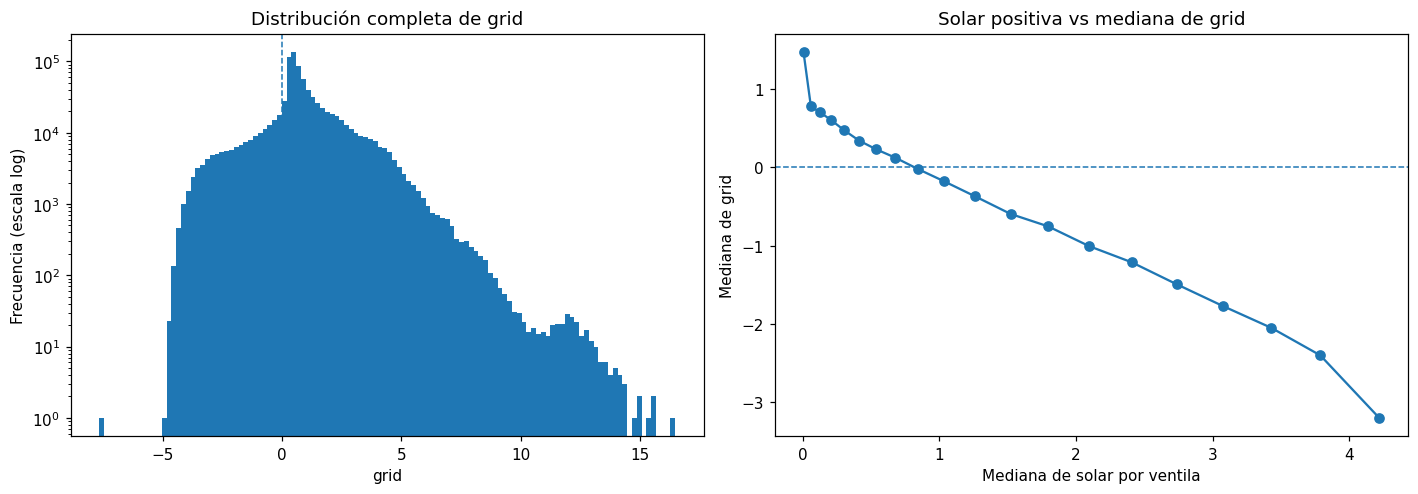

In [24]:
# [S06-C01] Distribución de grid, solar y relación descriptiva
# Rol: Temporal EDA Analyst
# Estado: REALIZADO

grid_stats = con.execute("""
SELECT
    COUNT(*) AS n_total,
    COUNT(grid) AS n_observed,
    COUNT(*) - COUNT(grid) AS n_missing,
    100.0 * (COUNT(*) - COUNT(grid)) / COUNT(*) AS pct_missing,
    AVG(grid) AS mean,
    MEDIAN(grid) AS median,
    STDDEV_SAMP(grid) AS std,
    MIN(grid) AS min,
    QUANTILE_CONT(grid, 0.01) AS P01,
    QUANTILE_CONT(grid, 0.05) AS P05,
    QUANTILE_CONT(grid, 0.25) AS P25,
    QUANTILE_CONT(grid, 0.75) AS P75,
    QUANTILE_CONT(grid, 0.95) AS P95,
    QUANTILE_CONT(grid, 0.99) AS P99,
    MAX(grid) AS max,
    100.0 * COUNT(*) FILTER (WHERE grid < 0) / COUNT(grid) AS pct_negative
FROM measurements_analytic
""").df()

solar_stats = con.execute("""
SELECT
    COUNT(*) AS n_total,
    COUNT(solar) AS n_observed,
    COUNT(*) - COUNT(solar) AS n_missing,
    100.0 * (COUNT(*) - COUNT(solar)) / COUNT(*) AS pct_missing,
    AVG(solar) AS mean,
    MEDIAN(solar) AS median,
    MIN(solar) AS min,
    QUANTILE_CONT(solar, 0.25) AS P25,
    QUANTILE_CONT(solar, 0.75) AS P75,
    QUANTILE_CONT(solar, 0.95) AS P95,
    QUANTILE_CONT(solar, 0.99) AS P99,
    MAX(solar) AS max,
    100.0 * COUNT(*) FILTER (WHERE solar < 0) / COUNT(solar) AS pct_negative,
    100.0 * COUNT(*) FILTER (WHERE solar = 0) / COUNT(solar) AS pct_zero,
    100.0 * COUNT(*) FILTER (WHERE solar > 0) / COUNT(solar) AS pct_positive
FROM measurements_analytic
""").df()

energy_summary = pd.DataFrame([
    {
        "variable": "grid",
        "n_observed": grid_stats.loc[0, "n_observed"],
        "pct_missing": grid_stats.loc[0, "pct_missing"],
        "mean": grid_stats.loc[0, "mean"],
        "median": grid_stats.loc[0, "median"],
        "P95": grid_stats.loc[0, "P95"],
        "P99": grid_stats.loc[0, "P99"],
        "min": grid_stats.loc[0, "min"],
        "max": grid_stats.loc[0, "max"],
        "pct_negative": grid_stats.loc[0, "pct_negative"],
    },
    {
        "variable": "solar",
        "n_observed": solar_stats.loc[0, "n_observed"],
        "pct_missing": solar_stats.loc[0, "pct_missing"],
        "mean": solar_stats.loc[0, "mean"],
        "median": solar_stats.loc[0, "median"],
        "P95": solar_stats.loc[0, "P95"],
        "P99": solar_stats.loc[0, "P99"],
        "min": solar_stats.loc[0, "min"],
        "max": solar_stats.loc[0, "max"],
        "pct_negative": solar_stats.loc[0, "pct_negative"],
    },
])

solar_grid_relation = con.execute("""
SELECT
    COUNT(*) AS n_pairs,
    COUNT(DISTINCT dataid) AS n_homes,
    CORR(solar, grid) AS pearson_corr_solar_grid,
    100.0 * COUNT(*) FILTER (WHERE grid < 0) / COUNT(*) AS pct_grid_negative
FROM measurements_analytic
WHERE solar IS NOT NULL
  AND grid IS NOT NULL
""").df()

solar_grid_binned = con.execute("""
WITH positive_solar AS (
    SELECT
        solar,
        grid,
        NTILE(20) OVER (ORDER BY solar) AS solar_bin
    FROM measurements_analytic
    WHERE solar > 0
      AND grid IS NOT NULL
)
SELECT
    solar_bin,
    COUNT(*) AS n,
    MEDIAN(solar) AS solar_median,
    MEDIAN(grid) AS grid_median,
    100.0 * COUNT(*) FILTER (WHERE grid < 0) / COUNT(*) AS pct_grid_negative
FROM positive_solar
GROUP BY solar_bin
ORDER BY solar_bin
""").df()

show_table(
    energy_summary,
    "Resumen estadístico de las variables energéticas centrales",
    descriptions={
        "n_observed": "Cantidad de valores no nulos.",
        "pct_missing": "Porcentaje faltante sobre todas las filas.",
        "mean": "Media aritmética de los valores observados.",
        "median": "Mediana de los valores observados.",
        "P95": "Percentil 95 de los valores observados.",
        "P99": "Percentil 99 de los valores observados.",
        "min": "Mínimo observado.",
        "max": "Máximo observado.",
        "pct_negative": "Porcentaje de valores negativos entre los observados.",
    },
    max_rows=None,
)

show_table(
    solar_grid_relation,
    "Relación descriptiva entre solar y grid",
    descriptions={
        "n_pairs": "Cantidad de filas donde solar y grid están observados simultáneamente.",
        "pearson_corr_solar_grid": "Correlación lineal descriptiva entre solar y grid.",
        "pct_grid_negative": "Porcentaje de grid negativo dentro de los pares válidos.",
    },
    max_rows=None,
)

grid_values = con.execute("""
SELECT grid
FROM measurements_analytic
WHERE grid IS NOT NULL
""").df()["grid"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].hist(grid_values, bins=120, log=True)
axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].set_title("Distribución completa de grid")
axes[0].set_xlabel("grid")
axes[0].set_ylabel("Frecuencia (escala log)")

axes[1].plot(
    solar_grid_binned["solar_median"],
    solar_grid_binned["grid_median"],
    marker="o",
)
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_title("Solar positiva vs mediana de grid")
axes[1].set_xlabel("Mediana de solar por ventila")
axes[1].set_ylabel("Mediana de grid")

fig.tight_layout()
plt.show()

### Hallazgos
`grid` presenta una distribución asimétrica: **media 0,858, mediana 0,604, P95 = 3,941 y P99 = 5,689**, con un máximo de 16,461. Los valores negativos forman una parte relevante de la distribución y se preservan porque describen el sentido del intercambio con la red.

`solar` tiene **24,42% de faltantes**; entre sus valores observados aparecen ceros, positivos y pequeños negativos, sin evidencia suficiente para corregir estos últimos. En los **659.989 pares válidos de 20 hogares**, `solar` y `grid` muestran una correlación descriptiva de aproximadamente **−0,536**. Los bins de solar positiva muestran una caída progresiva de la mediana de `grid` a medida que aumenta `solar`, pero esta asociación no se interpreta como causalidad sobre el consumo bruto del hogar.

# 7. Patrones temporales

### Problema y objetivo
Una serie eléctrica residencial no es estacionaria a lo largo del día ni del año. Antes de diseñar features necesitamos identificar qué parte de la estructura de `grid` está asociada con el calendario.

**Preguntas**
- ¿A qué horas aumenta o disminuye el intercambio neto?
- ¿Cambian los perfiles entre lunes–viernes y fines de semana?
- ¿La combinación mes × hora revela patrones más fuertes que un promedio global?

Toda interpretación se hace con `ts_local`, porque una hora civil debe representar la hora realmente vivida en Austin.

,month,n,mean,median,P95,pct_negative
Descripción,"Mes local de Austin, de 1 a 12.",Cantidad de observaciones válidas de grid.,Media de grid en el mes.,Mediana de grid en el mes.,Percentil 95 de grid en el mes.,Porcentaje mensual de observaciones con grid < 0.
1,1,"72,354",0.523,0.545,3.015,20.394
2,2,"67,064",0.654,0.523,2.782,14.349
3,3,"73,915",0.342,0.437,2.719,22.392
4,4,"71,995",0.291,0.429,2.724,23.667
5,5,"73,632",1.001,0.708,4.250,18.184
6,6,"72,000",1.334,1.062,4.463,15.206
7,7,"71,284",1.580,1.331,4.704,12.753
8,8,"73,624",1.581,1.331,4.741,12.944
9,9,"71,996",1.219,0.874,4.264,14.149


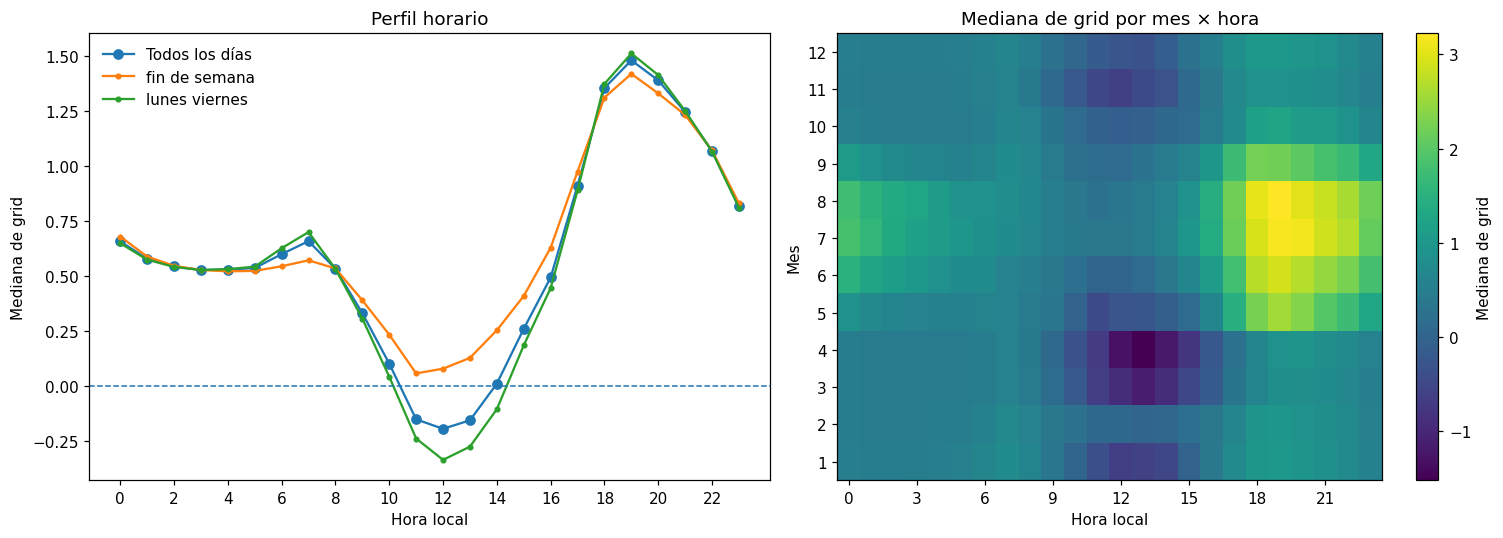

In [25]:
# [S07-C01] Perfiles horarios, semanales y mensuales
# Rol: Temporal EDA Analyst
# Estado: REALIZADO

grid_hourly_profile = con.execute("""
SELECT
    hour,
    COUNT(grid) AS n,
    AVG(grid) AS mean,
    MEDIAN(grid) AS median,
    QUANTILE_CONT(grid, 0.25) AS P25,
    QUANTILE_CONT(grid, 0.75) AS P75,
    QUANTILE_CONT(grid, 0.95) AS P95,
    100.0 * COUNT(*) FILTER (WHERE grid < 0) / COUNT(grid) AS pct_negative
FROM measurements_analytic
WHERE grid IS NOT NULL
GROUP BY hour
ORDER BY hour
""").df()

grid_hourly_daytype = con.execute("""
SELECT
    CASE
        WHEN is_weekend THEN 'fin_de_semana'
        ELSE 'lunes_viernes'
    END AS day_type,
    hour,
    COUNT(grid) AS n,
    MEDIAN(grid) AS median,
    100.0 * COUNT(*) FILTER (WHERE grid < 0) / COUNT(grid) AS pct_negative
FROM measurements_analytic
WHERE grid IS NOT NULL
GROUP BY day_type, hour
ORDER BY day_type, hour
""").df()

grid_monthly_profile = con.execute("""
SELECT
    month,
    COUNT(grid) AS n,
    AVG(grid) AS mean,
    MEDIAN(grid) AS median,
    QUANTILE_CONT(grid, 0.95) AS P95,
    100.0 * COUNT(*) FILTER (WHERE grid < 0) / COUNT(grid) AS pct_negative
FROM measurements_analytic
WHERE grid IS NOT NULL
GROUP BY month
ORDER BY month
""").df()

grid_hour_month = con.execute("""
SELECT
    month,
    hour,
    COUNT(grid) AS n,
    MEDIAN(grid) AS median_grid
FROM measurements_analytic
WHERE grid IS NOT NULL
GROUP BY month, hour
ORDER BY month, hour
""").df()

show_table(
    grid_monthly_profile,
    "Perfil mensual de grid",
    descriptions={
        "month": "Mes local de Austin, de 1 a 12.",
        "n": "Cantidad de observaciones válidas de grid.",
        "mean": "Media de grid en el mes.",
        "median": "Mediana de grid en el mes.",
        "P95": "Percentil 95 de grid en el mes.",
        "pct_negative": "Porcentaje mensual de observaciones con grid < 0.",
    },
    max_rows=None,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    grid_hourly_profile["hour"],
    grid_hourly_profile["median"],
    marker="o",
    label="Todos los días",
)

for label, group in grid_hourly_daytype.groupby("day_type"):
    axes[0].plot(
        group["hour"],
        group["median"],
        marker=".",
        label=label.replace("_", " "),
    )

axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_xlabel("Hora local")
axes[0].set_ylabel("Mediana de grid")
axes[0].set_title("Perfil horario")
axes[0].legend()

heatmap = (
    grid_hour_month
    .pivot(
        index="month",
        columns="hour",
        values="median_grid",
    )
    .reindex(
        index=range(1, 13),
        columns=range(24),
    )
)

image = axes[1].imshow(
    heatmap.values,
    aspect="auto",
    origin="lower",
)
axes[1].set_xlabel("Hora local")
axes[1].set_ylabel("Mes")
axes[1].set_title("Mediana de grid por mes × hora")
axes[1].set_xticks(range(0, 24, 3))
axes[1].set_yticks(range(12))
axes[1].set_yticklabels(range(1, 13))

fig.colorbar(
    image,
    ax=axes[1],
    label="Mediana de grid",
)

fig.tight_layout()
plt.show()

### Hallazgos
El patrón intradiario es claro: durante madrugada la mediana se mantiene alrededor de 0,5–0,7; entre **11:00 y 13:00** pasa a valores centrales negativos y el porcentaje de `grid < 0` supera el 50%; por la tarde aumenta con fuerza y alcanza su mayor mediana cerca de **19:00 (≈1,48)**.

Lunes–viernes y fines de semana comparten la forma general, pero difieren principalmente durante mañana y mediodía. La matriz mes × hora agrega otra dimensión: **julio y agosto presentan las medianas más altas en la franja 18–20 h**, mientras que marzo–abril muestran valores más negativos al mediodía. Esto justifica conservar hora, mes, día de semana y fin de semana como features candidatas, sin atribuir los patrones a clima u otras causas no observadas.

# 8. Cobertura y continuidad

### Problema y objetivo
Un agregado puede bajar porque cae la demanda real o simplemente porque faltan hogares. Antes de sumar o comparar timestamps debemos reconstruir la grilla completa de 15 minutos y separar dos mecanismos distintos:

1. **fila ausente**;
2. **fila presente con `grid = NULL`**.

**Preguntas**
- ¿Cuántos intervalos deberían existir en 2018 y cuántos faltan por completo?
- ¿Qué tan frecuente es observar los 25 hogares simultáneamente?
- ¿Existen períodos prolongados de cobertura reducida?
- ¿Cómo afecta DST a la cantidad esperada de intervalos locales?

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,metrica,valor
Descripción,Nombre de la métrica o control.,Valor observado de la métrica.
1,timestamps_esperados,"35,040"
2,timestamps_con_alguna_fila,"35,036"
3,timestamps_sin_ninguna_fila,4
4,timestamps_con_25_grid_validos,"29,241"
5,dias_con_intervalo_incompleto,92
6,eventos_cobertura_incompleta,120
7,max_intervalos_consecutivos_incompletos,"1,888"


,n_grid_valid,n_timestamps,pct_timestamps
Descripción,Cantidad de hogares con grid válido en el timestamp.,Cantidad de timestamps con esa cobertura.,Porcentaje de la grilla anual con esa cobertura.
1,25,"29,241",83.450
2,24,"4,967",14.175
3,23,312,0.890
4,22,136,0.388
5,21,320,0.913
6,20,4,0.011
7,16,55,0.157
8,15,1,0.003
9,0,4,0.011


,dataid,n_rows,n_grid_valid,n_grid_missing_in_rows,n_missing_rows_expected,grid_coverage_ratio_expected
Descripción,Identificador único del hogar.,Cantidad de filas o registros.,Cantidad de observaciones válidas de grid.,Filas existentes donde grid es NULL.,Timestamps esperados donde no existe fila del hogar.,Grid válido dividido por los 35.040 timestamps esperados.
1,"9,278","35,035","32,555","2,480",5,0.929
2,"9,922","35,036","33,544","1,492",4,0.957
3,"2,335","34,468","34,467",1,572,0.984
4,"1,642","34,648","34,468",180,392,0.984
5,"3,039","35,036","34,512",524,4,0.985
6,"4,373","34,532","34,528",4,508,0.985


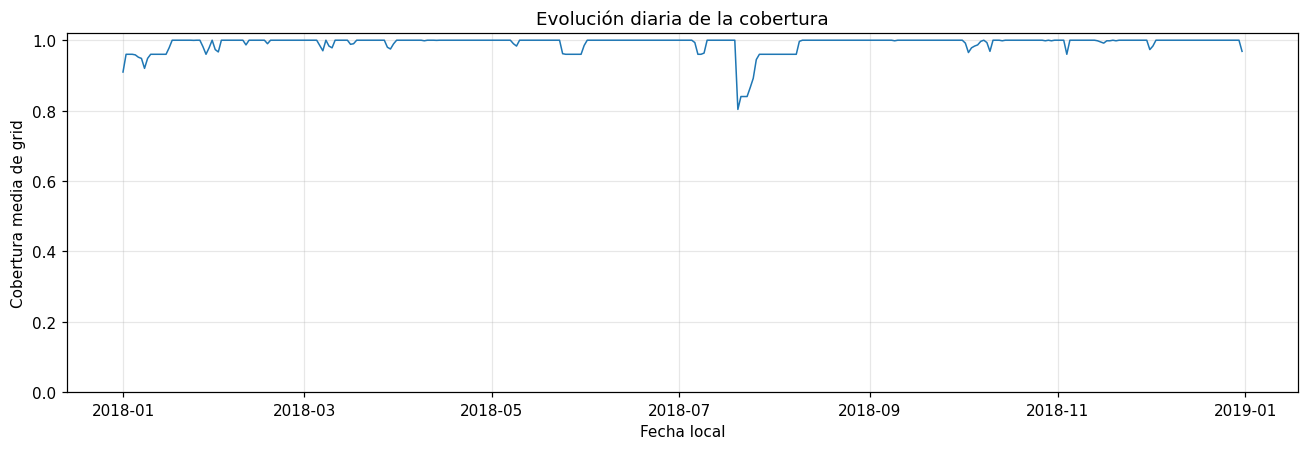

In [26]:
# [S08-C01] Grilla esperada, cobertura por timestamp y continuidad
# Rol: Data Quality / Temporal Coverage Analyst
# Estado: REALIZADO

N_HOMES_TOTAL = int(
    con.execute("""
        SELECT COUNT(DISTINCT dataid)
        FROM measurements_analytic
    """).fetchone()[0]
)

timestamp_coverage_df = con.execute(f"""
WITH bounds AS (
    SELECT
        MIN(ts_utc) AS min_ts,
        MAX(ts_utc) AS max_ts
    FROM measurements_analytic
),
expected AS (
    SELECT
        UNNEST(
            generate_series(
                min_ts,
                max_ts,
                INTERVAL {EXPECTED_FREQ_MIN} MINUTE
            )
        ) AS ts_utc
    FROM bounds
),
observed AS (
    SELECT
        ts_utc,
        COUNT(DISTINCT dataid) AS n_homes_rows,
        COUNT(
            DISTINCT CASE
                WHEN grid IS NOT NULL THEN dataid
            END
        ) AS n_grid_valid,
        COUNT(
            DISTINCT CASE
                WHEN grid IS NULL THEN dataid
            END
        ) AS n_grid_missing_among_rows
    FROM measurements_analytic
    GROUP BY ts_utc
)
SELECT
    e.ts_utc,
    {N_HOMES_TOTAL} AS n_homes_total,
    COALESCE(o.n_homes_rows, 0) AS n_homes_rows,
    COALESCE(o.n_grid_valid, 0) AS n_grid_valid,
    COALESCE(o.n_grid_missing_among_rows, 0) AS n_grid_missing_among_rows,
    COALESCE(o.n_homes_rows, 0)::DOUBLE / {N_HOMES_TOTAL} AS row_coverage_ratio,
    COALESCE(o.n_grid_valid, 0)::DOUBLE / {N_HOMES_TOTAL} AS grid_coverage_ratio
FROM expected e
LEFT JOIN observed o
    USING (ts_utc)
ORDER BY e.ts_utc
""").df()

try:
    con.unregister("timestamp_coverage")
except Exception:
    pass

con.register("timestamp_coverage", timestamp_coverage_df)

coverage_distribution = (
    timestamp_coverage_df
    .groupby("n_grid_valid", as_index=False)
    .agg(n_timestamps=("ts_utc", "size"))
    .sort_values("n_grid_valid", ascending=False)
)

coverage_distribution["pct_timestamps"] = (
    100.0
    * coverage_distribution["n_timestamps"]
    / len(timestamp_coverage_df)
)

coverage_daily_work = timestamp_coverage_df.copy()

utc_series = pd.to_datetime(
    coverage_daily_work["ts_utc"],
    utc=True,
)

local_series = utc_series.dt.tz_convert(LOCAL_TZ)

coverage_daily_work["local_date"] = local_series.dt.date

daily_coverage = (
    coverage_daily_work
    .groupby("local_date", as_index=False)
    .agg(
        n_expected_intervals=("ts_utc", "size"),
        mean_grid_coverage=("grid_coverage_ratio", "mean"),
        min_grid_coverage=("grid_coverage_ratio", "min"),
        n_incomplete_intervals=(
            "n_grid_valid",
            lambda x: int((x < N_HOMES_TOTAL).sum()),
        ),
        n_zero_coverage=(
            "n_grid_valid",
            lambda x: int((x == 0).sum()),
        ),
    )
)

N_EXPECTED_TIMESTAMPS = len(timestamp_coverage_df)

household_coverage = con.execute(f"""
SELECT
    dataid,
    {N_EXPECTED_TIMESTAMPS} AS n_expected_timestamps,
    COUNT(*) AS n_rows,
    COUNT(grid) AS n_grid_valid,
    COUNT(*) - COUNT(grid) AS n_grid_missing_in_rows,
    {N_EXPECTED_TIMESTAMPS} - COUNT(*) AS n_missing_rows_expected,
    COUNT(*)::DOUBLE / {N_EXPECTED_TIMESTAMPS} AS row_coverage_ratio,
    COUNT(grid)::DOUBLE / {N_EXPECTED_TIMESTAMPS} AS grid_coverage_ratio_expected,
    COUNT(grid)::DOUBLE / COUNT(*) AS grid_valid_pct_within_rows,
    MIN(ts_utc) AS first_ts_utc,
    MAX(ts_utc) AS last_ts_utc
FROM measurements_analytic
GROUP BY dataid
ORDER BY dataid
""").df()

incomplete = (
    timestamp_coverage_df.loc[
        timestamp_coverage_df["n_grid_valid"] < N_HOMES_TOTAL
    ]
    .copy()
    .reset_index(drop=True)
)

if not incomplete.empty:
    incomplete["new_event"] = (
        incomplete["ts_utc"]
        .diff()
        .ne(pd.Timedelta(minutes=EXPECTED_FREQ_MIN))
    )

    incomplete["event_id"] = incomplete["new_event"].cumsum()

    coverage_events = (
        incomplete
        .groupby("event_id", as_index=False)
        .agg(
            start_ts_utc=("ts_utc", "min"),
            end_ts_utc=("ts_utc", "max"),
            n_intervals=("ts_utc", "size"),
            min_grid_valid=("n_grid_valid", "min"),
            max_grid_valid=("n_grid_valid", "max"),
            mean_grid_coverage=("grid_coverage_ratio", "mean"),
            contains_zero_coverage=(
                "n_grid_valid",
                lambda x: bool((x == 0).any()),
            ),
            contains_zero_rows=(
                "n_homes_rows",
                lambda x: bool((x == 0).any()),
            ),
        )
    )

    coverage_events["duration_minutes"] = (
        coverage_events["n_intervals"]
        * EXPECTED_FREQ_MIN
    )
else:
    coverage_events = pd.DataFrame()

coverage_summary = pd.DataFrame([
    {
        "metrica": "timestamps_esperados",
        "valor": len(timestamp_coverage_df),
    },
    {
        "metrica": "timestamps_con_alguna_fila",
        "valor": int((timestamp_coverage_df["n_homes_rows"] > 0).sum()),
    },
    {
        "metrica": "timestamps_sin_ninguna_fila",
        "valor": int((timestamp_coverage_df["n_homes_rows"] == 0).sum()),
    },
    {
        "metrica": "timestamps_con_25_grid_validos",
        "valor": int(
            (
                timestamp_coverage_df["n_grid_valid"]
                == N_HOMES_TOTAL
            ).sum()
        ),
    },
    {
        "metrica": "dias_con_intervalo_incompleto",
        "valor": int(
            (
                daily_coverage["n_incomplete_intervals"] > 0
            ).sum()
        ),
    },
    {
        "metrica": "eventos_cobertura_incompleta",
        "valor": len(coverage_events),
    },
    {
        "metrica": "max_intervalos_consecutivos_incompletos",
        "valor": int(coverage_events["n_intervals"].max()),
    },
])

show_table(
    coverage_summary,
    "Resumen de cobertura y continuidad",
    max_rows=None,
)

show_table(
    coverage_distribution,
    "Distribución de hogares con grid válido por timestamp",
    descriptions={
        "n_grid_valid": "Cantidad de hogares con grid válido en el timestamp.",
        "n_timestamps": "Cantidad de timestamps con esa cobertura.",
        "pct_timestamps": "Porcentaje de la grilla anual con esa cobertura.",
    },
    max_rows=None,
)

show_table(
    household_coverage.nsmallest(
        6,
        "grid_coverage_ratio_expected",
    )[
        [
            "dataid",
            "n_rows",
            "n_grid_valid",
            "n_grid_missing_in_rows",
            "n_missing_rows_expected",
            "grid_coverage_ratio_expected",
        ]
    ],
    "Hogares con menor cobertura de grid",
    descriptions={
        "n_grid_missing_in_rows": "Filas existentes donde grid es NULL.",
        "n_missing_rows_expected": "Timestamps esperados donde no existe fila del hogar.",
        "grid_coverage_ratio_expected": "Grid válido dividido por los 35.040 timestamps esperados.",
    },
    max_rows=None,
)

fig, ax = plt.subplots(figsize=(12, 4.2))

ax.plot(
    pd.to_datetime(daily_coverage["local_date"]),
    daily_coverage["mean_grid_coverage"],
    linewidth=1,
)

ax.set_ylim(0, 1.02)
ax.set_xlabel("Fecha local")
ax.set_ylabel("Cobertura media de grid")
ax.set_title("Evolución diaria de la cobertura")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

### Hallazgos
La grilla anual contiene **35.040 intervalos esperados**. En la fuente existen **35.036 timestamps**, por lo que sólo **4 intervalos están completamente ausentes para los 25 hogares**; corresponden a 2018-11-04 06:00–06:45 UTC. El día de primavera de DST tiene correctamente 92 intervalos locales y el de otoño 100; por lo tanto, los cambios de reloj no deben confundirse con faltantes.

En **83,45%** de la grilla hay 25 hogares con `grid` válido y en **14,18%** hay 24. Sin embargo, aparecen períodos prolongados de cobertura reducida: el mayor evento reúne **1.888 intervalos consecutivos (≈19,7 días)**. Además, la cobertura por hogar muestra dos mecanismos diferentes —filas ausentes y `grid NULL` dentro de filas existentes—. Por esto, cualquier agregado posterior debe conservar `n_hogares_validos` y `coverage_ratio`; **una caída del total observado puede ser sólo una caída de cobertura**.

# 9. Eventos de alto `grid`

### Problema y objetivo
Los percentiles globales permiten estudiar la cola superior, pero una observación alta aislada no es lo mismo que un episodio persistente. Necesitamos pasar de valores individuales a **eventos consecutivos por hogar**.

**Preguntas**
- ¿Cuáles son los P95 y P99 globales de `grid`?
- ¿En qué horas y meses se concentran las observaciones altas?
- ¿Cuánto duran los eventos consecutivos?
- ¿Son episodios reales o podrían estar producidos por gaps?

Los thresholds son **exploratorios**. No equivalen todavía al target definitivo.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,threshold,threshold_value,n_grid_observed,n_peak_observations,pct_peak_observations,n_homes_with_peak,n_events,n_homes_with_events,median_intervals,P95_intervals,max_intervals,median_duration_minutes,P95_duration_minutes,max_duration_minutes,n_inter_event_gaps,median_hours_between_events,P95_hours_between_events
Descripción,Umbral exploratorio utilizado.,Valor numérico del umbral.,Cantidad total de observaciones válidas usadas para calcular el percentil.,Cantidad de observaciones iguales o superiores al threshold.,Porcentaje de observaciones válidas que supera el threshold.,Hogares con al menos una observación sobre el threshold.,Cantidad de eventos consecutivos.,Hogares con al menos un evento consecutivo.,Mediana de intervalos consecutivos por evento.,Percentil 95 de la longitud de los eventos en intervalos.,Mayor cantidad de intervalos consecutivos observada.,Duración mediana de los eventos.,Percentil 95 de duración de eventos.,Duración máxima de un evento.,Cantidad asociada a inter event gaps.,Mediana de horas entre inicios de eventos sucesivos por hogar.,Percentil 95 de horas entre inicios de eventos.
1,P95,3.941,"868,096","43,432",5.003,25,"16,744",25,1.000,9.000,69,15.000,135.000,"1,035","16,719",1.750,43.750
2,P99,5.689,"868,096","8,688",1.001,21,"4,270",21,1.000,6.000,34,15.000,90.000,510,"4,249",3.750,143.750


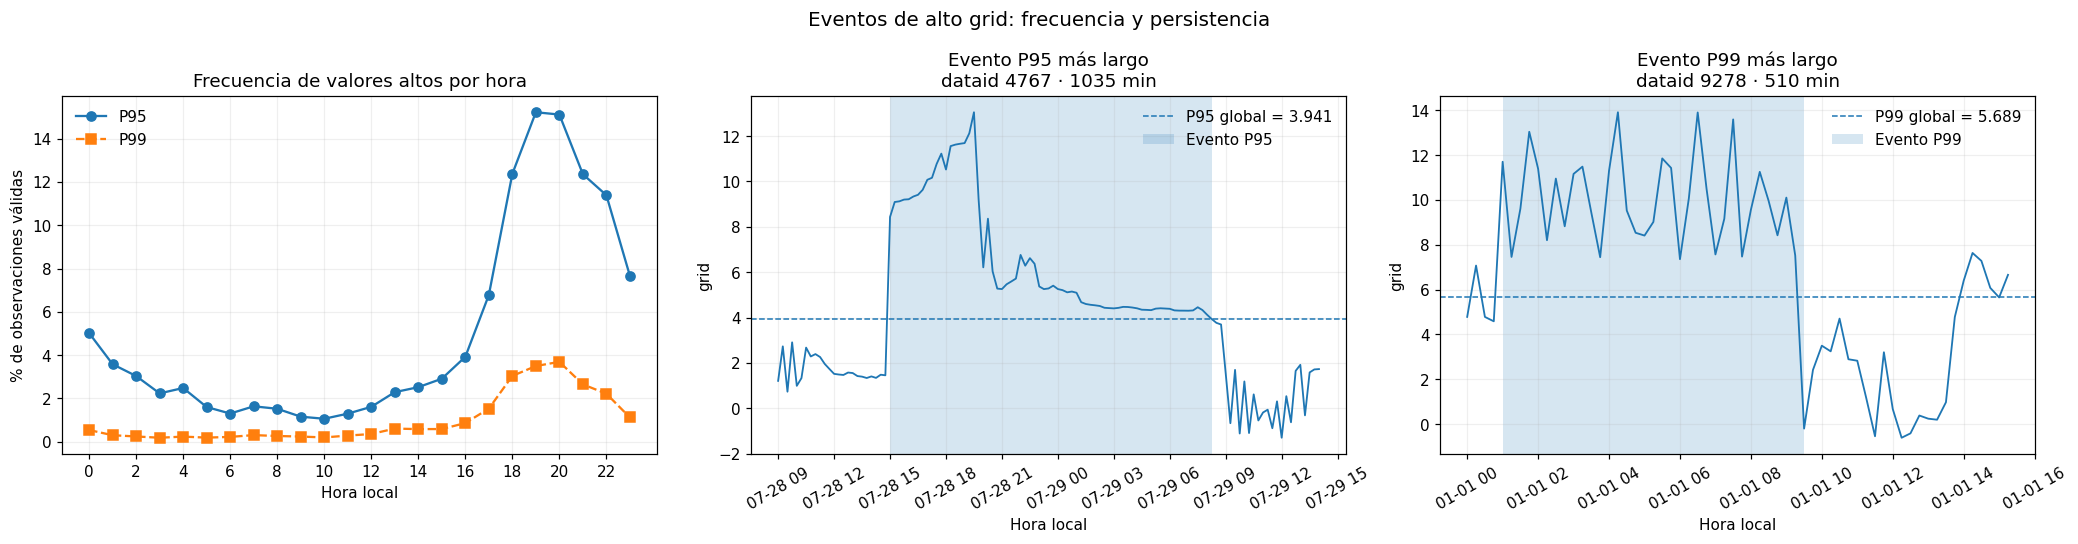

In [27]:
# [S09-C01] Umbrales globales, eventos consecutivos y recurrencia
# Rol: Peak Event / Temporal EDA Analyst
# Estado: REALIZADO

con.execute("""
CREATE OR REPLACE TEMP TABLE peak_thresholds AS
WITH q AS (
    SELECT
        QUANTILE_CONT(grid, 0.95) AS p95,
        QUANTILE_CONT(grid, 0.99) AS p99,
        COUNT(grid) AS n_grid_observed
    FROM measurements_analytic
    WHERE grid IS NOT NULL
),
thresholds AS (
    SELECT 'P95' AS threshold, p95 AS threshold_value, n_grid_observed FROM q
    UNION ALL
    SELECT 'P99', p99, n_grid_observed FROM q
)
SELECT
    t.threshold,
    t.threshold_value,
    t.n_grid_observed,
    COUNT(m.grid) AS n_peak_observations,
    100.0 * COUNT(m.grid) / t.n_grid_observed AS pct_peak_observations,
    COUNT(DISTINCT m.dataid) AS n_homes_with_peak
FROM thresholds t
LEFT JOIN measurements_analytic m
    ON m.grid IS NOT NULL
   AND m.grid >= t.threshold_value
GROUP BY
    t.threshold,
    t.threshold_value,
    t.n_grid_observed
ORDER BY t.threshold
""")

peak_thresholds_df = con.execute("""
SELECT *
FROM peak_thresholds
ORDER BY threshold
""").df()

P95_THRESHOLD = float(
    peak_thresholds_df.loc[
        peak_thresholds_df["threshold"] == "P95",
        "threshold_value",
    ].iloc[0]
)

P99_THRESHOLD = float(
    peak_thresholds_df.loc[
        peak_thresholds_df["threshold"] == "P99",
        "threshold_value",
    ].iloc[0]
)

peak_hourly_profile = con.execute(f"""
SELECT
    hour,
    COUNT(*) AS n_grid_valid,
    100.0 * COUNT(*) FILTER (
        WHERE grid >= {P95_THRESHOLD}
    ) / COUNT(*) AS pct_p95,
    100.0 * COUNT(*) FILTER (
        WHERE grid >= {P99_THRESHOLD}
    ) / COUNT(*) AS pct_p99
FROM measurements_analytic
WHERE grid IS NOT NULL
GROUP BY hour
ORDER BY hour
""").df()

peak_monthly_profile = con.execute(f"""
SELECT
    month,
    COUNT(*) AS n_grid_valid,
    100.0 * COUNT(*) FILTER (
        WHERE grid >= {P95_THRESHOLD}
    ) / COUNT(*) AS pct_p95,
    100.0 * COUNT(*) FILTER (
        WHERE grid >= {P99_THRESHOLD}
    ) / COUNT(*) AS pct_p99
FROM measurements_analytic
WHERE grid IS NOT NULL
GROUP BY month
ORDER BY month
""").df()

con.execute("""
CREATE OR REPLACE TEMP TABLE peak_events AS
WITH peak_observations AS (
    SELECT
        t.threshold,
        m.dataid,
        m.ts_utc,
        m.ts_local,
        m.grid
    FROM peak_thresholds t
    JOIN measurements_analytic m
      ON m.grid IS NOT NULL
     AND m.grid >= t.threshold_value
),
flagged AS (
    SELECT
        *,
        CASE
            WHEN LAG(ts_utc) OVER w IS NULL THEN 1
            WHEN date_diff(
                'second',
                LAG(ts_utc) OVER w,
                ts_utc
            ) <> 900 THEN 1
            ELSE 0
        END AS is_new_event
    FROM peak_observations
    WINDOW w AS (
        PARTITION BY threshold, dataid
        ORDER BY ts_utc
    )
),
sequenced AS (
    SELECT
        *,
        SUM(is_new_event) OVER (
            PARTITION BY threshold, dataid
            ORDER BY ts_utc
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS event_seq
    FROM flagged
)
SELECT
    threshold,
    dataid,
    event_seq,
    threshold
        || '_'
        || CAST(dataid AS VARCHAR)
        || '_'
        || LPAD(CAST(event_seq AS VARCHAR), 4, '0')
        AS event_id,
    MIN(ts_utc) AS start_ts_utc,
    MAX(ts_utc) AS end_ts_utc,
    ARG_MIN(ts_local, ts_utc) AS start_ts_local,
    ARG_MAX(ts_local, ts_utc) AS end_ts_local,
    COUNT(*) AS n_intervals,
    COUNT(*) * 15 AS duration_minutes,
    AVG(grid) AS mean_grid,
    MEDIAN(grid) AS median_grid,
    MAX(grid) AS max_grid
FROM sequenced
GROUP BY
    threshold,
    dataid,
    event_seq
""")

peak_event_summary = con.execute("""
SELECT
    threshold,
    COUNT(*) AS n_events,
    SUM(n_intervals) AS n_peak_observations,
    COUNT(DISTINCT dataid) AS n_homes_with_events,
    MEDIAN(n_intervals) AS median_intervals,
    QUANTILE_CONT(n_intervals, 0.95) AS P95_intervals,
    MAX(n_intervals) AS max_intervals,
    MEDIAN(duration_minutes) AS median_duration_minutes,
    QUANTILE_CONT(duration_minutes, 0.95) AS P95_duration_minutes,
    MAX(duration_minutes) AS max_duration_minutes
FROM peak_events
GROUP BY threshold
ORDER BY threshold
""").df()

peak_recurrence_summary = con.execute("""
WITH recurrence AS (
    SELECT
        threshold,
        dataid,
        date_diff(
            'second',
            LAG(start_ts_utc) OVER (
                PARTITION BY threshold, dataid
                ORDER BY start_ts_utc
            ),
            start_ts_utc
        ) / 3600.0 AS hours_since_previous_event
    FROM peak_events
)
SELECT
    threshold,
    COUNT(hours_since_previous_event) AS n_inter_event_gaps,
    MEDIAN(hours_since_previous_event) AS median_hours_between_events,
    QUANTILE_CONT(hours_since_previous_event, 0.95)
        AS P95_hours_between_events
FROM recurrence
GROUP BY threshold
ORDER BY threshold
""").df()

peak_summary = (
    peak_thresholds_df
    .merge(
        peak_event_summary,
        on=["threshold", "n_peak_observations"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        peak_recurrence_summary,
        on="threshold",
        how="left",
        validate="one_to_one",
    )
)

show_table(
    peak_summary,
    "Resumen de la cola superior y sus eventos",
    descriptions={
        "n_grid_observed": "Cantidad total de observaciones válidas usadas para calcular el percentil.",
        "n_peak_observations": "Cantidad de observaciones iguales o superiores al threshold.",
        "pct_peak_observations": "Porcentaje de observaciones válidas que supera el threshold.",
        "n_homes_with_peak": "Hogares con al menos una observación sobre el threshold.",
        "n_homes_with_events": "Hogares con al menos un evento consecutivo.",
        "median_intervals": "Mediana de intervalos consecutivos por evento.",
        "P95_intervals": "Percentil 95 de la longitud de los eventos en intervalos.",
        "max_intervals": "Mayor cantidad de intervalos consecutivos observada.",
        "median_duration_minutes": "Duración mediana de los eventos.",
        "P95_duration_minutes": "Percentil 95 de duración de eventos.",
        "max_duration_minutes": "Duración máxima de un evento.",
        "median_hours_between_events": "Mediana de horas entre inicios de eventos sucesivos por hogar.",
        "P95_hours_between_events": "Percentil 95 de horas entre inicios de eventos.",
    },
    max_rows=None,
)

# ---------------------------------------------------------------------
# Eventos P95 y P99 más largos en contexto
# ---------------------------------------------------------------------

# Evento P95 más largo
longest_p95_event = con.execute("""
SELECT *
FROM peak_events
WHERE threshold = 'P95'
ORDER BY
    n_intervals DESC,
    max_grid DESC
LIMIT 1
""").df()

p95_event_id = longest_p95_event.loc[0, "event_id"]

longest_p95_context = con.execute("""
SELECT
    m.dataid,
    m.ts_utc,
    m.ts_local,
    m.grid
FROM measurements_analytic m
JOIN (
    SELECT
        dataid,
        start_ts_utc,
        end_ts_utc
    FROM peak_events
    WHERE event_id = ?
) e
  ON m.dataid = e.dataid
 AND m.ts_utc BETWEEN
     e.start_ts_utc - INTERVAL 6 HOUR
     AND
     e.end_ts_utc + INTERVAL 6 HOUR
ORDER BY m.ts_utc
""", [p95_event_id]).df()


# Evento P99 más largo
longest_p99_event = con.execute("""
SELECT *
FROM peak_events
WHERE threshold = 'P99'
ORDER BY
    n_intervals DESC,
    max_grid DESC
LIMIT 1
""").df()

p99_event_id = longest_p99_event.loc[0, "event_id"]

longest_p99_context = con.execute("""
SELECT
    m.dataid,
    m.ts_utc,
    m.ts_local,
    m.grid
FROM measurements_analytic m
JOIN (
    SELECT
        dataid,
        start_ts_utc,
        end_ts_utc
    FROM peak_events
    WHERE event_id = ?
) e
  ON m.dataid = e.dataid
 AND m.ts_utc BETWEEN
     e.start_ts_utc - INTERVAL 6 HOUR
     AND
     e.end_ts_utc + INTERVAL 6 HOUR
ORDER BY m.ts_utc
""", [p99_event_id]).df()


# ---------------------------------------------------------------------
# Visualizaciones
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 5)
)

# ==================================================
# 1. Frecuencia de valores altos por hora
# ==================================================

axes[0].plot(
    peak_hourly_profile["hour"],
    peak_hourly_profile["pct_p95"],
    marker="o",
    label="P95",
)

axes[0].plot(
    peak_hourly_profile["hour"],
    peak_hourly_profile["pct_p99"],
    marker="s",
    linestyle="--",
    label="P99",
)

axes[0].set_xlabel("Hora local")
axes[0].set_ylabel("% de observaciones válidas")
axes[0].set_title("Frecuencia de valores altos por hora")
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(alpha=0.2)
axes[0].legend()


# ==================================================
# 2. Evento P95 más largo
# ==================================================

event_p95 = longest_p95_event.iloc[0]

axes[1].plot(
    longest_p95_context["ts_local"],
    longest_p95_context["grid"],
    linewidth=1.2,
)

axes[1].axhline(
    P95_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label=f"P95 global = {P95_THRESHOLD:.3f}",
)

axes[1].axvspan(
    event_p95["start_ts_local"],
    event_p95["end_ts_local"]
    + pd.Timedelta(minutes=15),
    alpha=0.18,
    label="Evento P95",
)

axes[1].set_xlabel("Hora local")
axes[1].set_ylabel("grid")
axes[1].set_title(
    "Evento P95 más largo\n"
    f"dataid {event_p95['dataid']} · "
    f"{int(event_p95['duration_minutes'])} min"
)

axes[1].legend()
axes[1].grid(alpha=0.2)
axes[1].tick_params(
    axis="x",
    rotation=30
)


# ==================================================
# 3. Evento P99 más largo
# ==================================================

event_p99 = longest_p99_event.iloc[0]

axes[2].plot(
    longest_p99_context["ts_local"],
    longest_p99_context["grid"],
    linewidth=1.2,
)

axes[2].axhline(
    P99_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label=f"P99 global = {P99_THRESHOLD:.3f}",
)

axes[2].axvspan(
    event_p99["start_ts_local"],
    event_p99["end_ts_local"]
    + pd.Timedelta(minutes=15),
    alpha=0.18,
    label="Evento P99",
)

axes[2].set_xlabel("Hora local")
axes[2].set_ylabel("grid")
axes[2].set_title(
    "Evento P99 más largo\n"
    f"dataid {event_p99['dataid']} · "
    f"{int(event_p99['duration_minutes'])} min"
)

axes[2].legend()
axes[2].grid(alpha=0.2)
axes[2].tick_params(
    axis="x",
    rotation=30
)


fig.suptitle(
    "Eventos de alto grid: frecuencia y persistencia",
    fontsize=13
)

fig.tight_layout()
plt.show()

### Hallazgos
Los thresholds globales son **P95 = 3,941** y **P99 = 5,689**. El criterio inclusivo `grid >= threshold` identifica **43.432 observaciones P95 (≈5,00%)** y **8.688 P99 (≈1,00%)**. La frecuencia se concentra con fuerza entre 18 y 21 h; alrededor de 19–20 h más del 15% de las observaciones horarias superan P95.

Las 43.432 observaciones P95 forman **16.744 eventos**, mientras que P99 forma **4.270**. La mediana de duración es 15 minutos, pero existen episodios prolongados: el máximo P95 alcanza **69 intervalos = 17,25 horas** y el máximo P99 **34 intervalos = 8,5 horas**. El P95 más largo (`dataid 4767`) no contiene `grid NULL` ni gaps en su ventana de control, por lo que no es un artefacto de continuidad.

La limitación decisiva aparece al final: estos son thresholds **globales**. Para saber si significan lo mismo en cada hogar debemos medir heterogeneidad individual.

# 10. Heterogeneidad entre hogares y metadata

### Problema y objetivo
Un P95 global puede ser excepcional para un hogar y relativamente frecuente para otro. Si ignoramos esa diferencia, una comparación puramente global puede ocultar comportamientos estructuralmente distintos entre viviendas.

**Preguntas**
- ¿Cuánto varían mediana, P95 y P99 entre hogares?
- ¿El P95 global representa aproximadamente 5% de las observaciones de cada hogar?
- ¿La heterogeneidad coincide descriptivamente con atributos como superficie o PV declarado?

Cada hogar pesa una sola vez en las comparaciones con metadata; así evitamos pseudorreplicación.


,statistic,median_grid,P95_grid,household_P99,pct_grid_negative,pct_above_global_P95
Descripción,"Resumen entre los 25 hogares: mínimo, mediana o máximo.",Mediana de grid para el conjunto indicado.,Percentil 95 de grid.,Percentil 99 calculado dentro de cada hogar.,Porcentaje de observaciones de grid menores que cero.,Porcentaje del hogar que supera el P95 global.
1,min,0.247,1.686,2.483,0.000,0.003
2,median,0.576,3.801,5.050,19.811,3.951
3,max,1.904,5.264,9.010,31.483,19.622


,metadata_variable,energy_metric,n_complete_homes,spearman_correlation
Descripción,Atributo estático de metadata.,Métrica energética calculada una vez por hogar.,Hogares con ambas variables disponibles.,Correlación Spearman descriptiva; no implica causalidad.
1,total_square_footage,median_grid,25,0.302
2,total_square_footage,P95_grid,25,0.656
3,total_square_footage,pct_grid_negative,25,0.082
4,total_square_footage,pct_above_global_P95,25,0.708
5,house_construction_year,median_grid,25,-0.013
6,house_construction_year,P95_grid,25,0.163
7,house_construction_year,pct_grid_negative,25,0.394
8,house_construction_year,pct_above_global_P95,25,0.278
9,total_amount_of_pv,median_grid,18,0.386


,pv_metadata_status,n_homes,median_of_household_median_grid,median_of_household_P95_grid,median_pct_grid_negative,median_pct_above_global_P95
Descripción,PV declarado o no declarado en los campos de metadata utilizados.,Cantidad de hogares distintos.,Mediana entre hogares de la mediana individual de grid.,Mediana entre hogares del P95 individual de grid.,Mediana entre hogares del porcentaje de grid negativo.,Mediana entre hogares del porcentaje que supera el P95 global.
1,declared,19,0.482,3.826,22.933,4.363
2,not_declared,6,0.724,3.374,0.000,2.722


,dataid,pv_plot_group,building_type,is_town_home
Descripción,Identificador del hogar.,Clasificación visual según si PV está declarado en los campos de metadata utilizados.,Tipo de vivienda declarado en metadata.,Indica si el hogar corresponde a Town Home.
1,5746,PV no declarado,Single-Family Home 001 (Master),No
2,7901,PV no declarado,Single-Family Home 001 (Master),No
3,7951,PV no declarado,Single-Family Home 001 (Master),No
4,8386,PV no declarado,Single-Family Home 001 (Master),No
5,9922,PV no declarado,Single-Family Home 001 (Master),No
6,8565,PV no declarado,Town Home,Sí


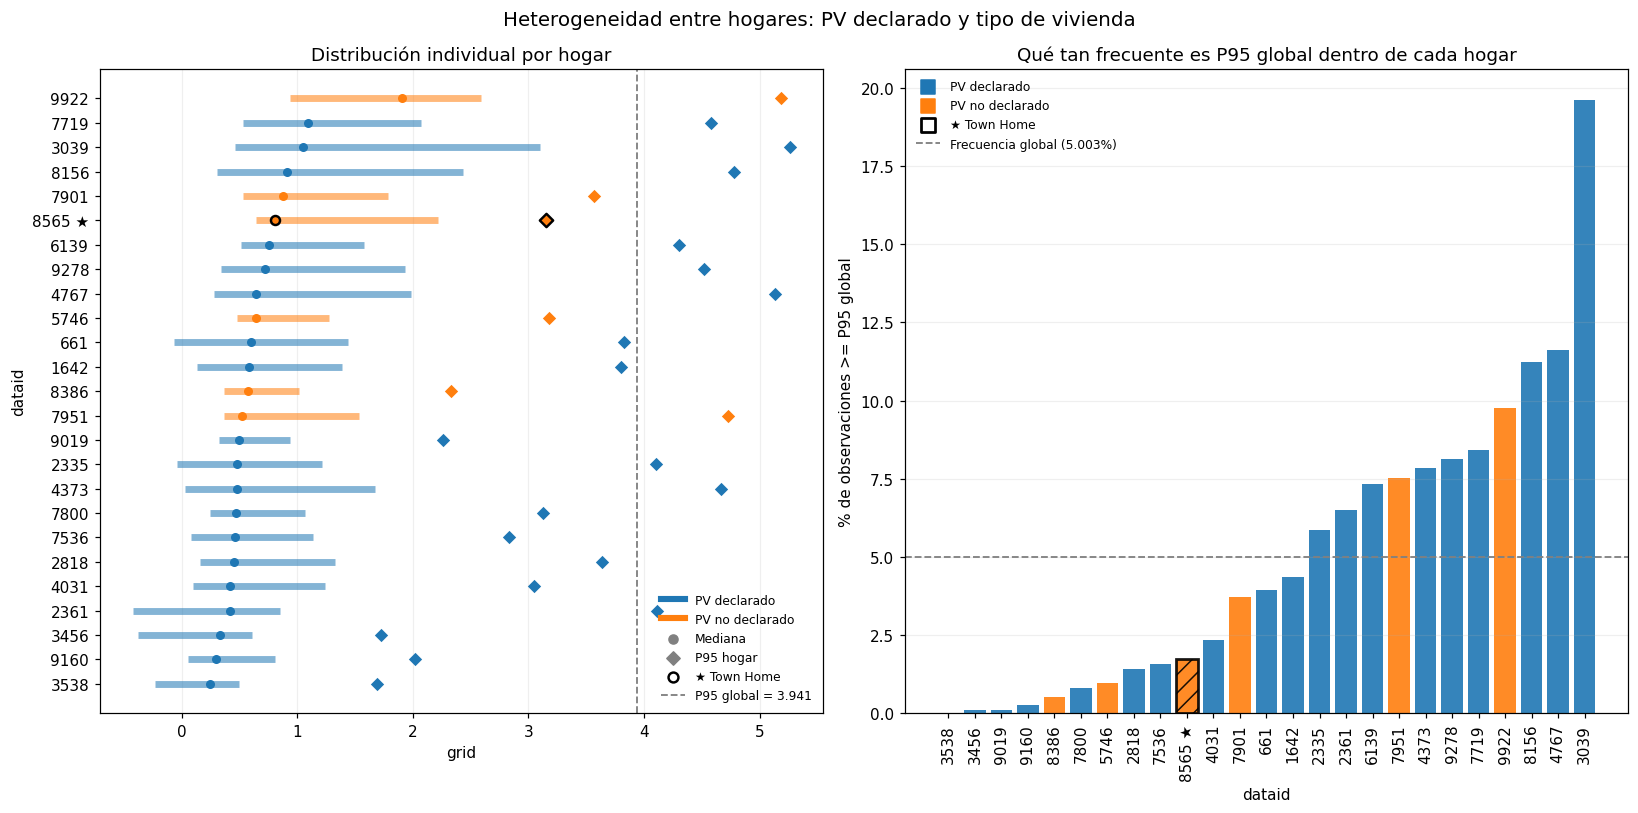

In [28]:
# [S10-C01] Perfil por hogar, thresholds globales y metadata
# Rol: Household Heterogeneity / Feature EDA Analyst
# Estado: REALIZADO

household_grid_profile = con.execute("""
SELECT
    dataid,
    COUNT(grid) AS n_grid_valid,
    AVG(grid) AS mean_grid,
    MEDIAN(grid) AS median_grid,
    STDDEV_SAMP(grid) AS std_grid,
    QUANTILE_CONT(grid, 0.05) AS P05_grid,
    QUANTILE_CONT(grid, 0.25) AS P25_grid,
    QUANTILE_CONT(grid, 0.75) AS P75_grid,
    QUANTILE_CONT(grid, 0.95) AS P95_grid,
    QUANTILE_CONT(grid, 0.99) AS P99_grid,
    COUNT(*) FILTER (WHERE grid < 0) AS n_grid_negative,
    100.0 * COUNT(*) FILTER (WHERE grid < 0) / COUNT(grid) AS pct_grid_negative
FROM measurements_analytic
WHERE grid IS NOT NULL
GROUP BY dataid
ORDER BY dataid
""").df()

household_grid_profile = (
    household_grid_profile
    .merge(
        household_coverage[
            [
                "dataid",
                "row_coverage_ratio",
                "grid_coverage_ratio_expected",
                "n_grid_missing_in_rows",
                "n_missing_rows_expected",
            ]
        ],
        on="dataid",
        how="left",
        validate="one_to_one",
    )
)

above_by_home = con.execute(f"""
SELECT
    dataid,
    COUNT(grid) AS n_grid_valid,
    COUNT(*) FILTER (
        WHERE grid >= {P95_THRESHOLD}
    ) AS n_above_global_P95,
    COUNT(*) FILTER (
        WHERE grid >= {P99_THRESHOLD}
    ) AS n_above_global_P99
FROM measurements_analytic
WHERE grid IS NOT NULL
GROUP BY dataid
ORDER BY dataid
""").df()

event_by_home = con.execute("""
SELECT
    dataid,
    COUNT(*) FILTER (
        WHERE threshold = 'P95'
    ) AS n_P95_events,
    MEDIAN(duration_minutes) FILTER (
        WHERE threshold = 'P95'
    ) AS median_P95_event_duration,
    MAX(duration_minutes) FILTER (
        WHERE threshold = 'P95'
    ) AS max_P95_event_duration,
    COUNT(*) FILTER (
        WHERE threshold = 'P99'
    ) AS n_P99_events,
    MEDIAN(duration_minutes) FILTER (
        WHERE threshold = 'P99'
    ) AS median_P99_event_duration,
    MAX(duration_minutes) FILTER (
        WHERE threshold = 'P99'
    ) AS max_P99_event_duration
FROM peak_events
GROUP BY dataid
ORDER BY dataid
""").df()

household_threshold_comparison = (
    household_grid_profile[
        [
            "dataid",
            "n_grid_valid",
            "P95_grid",
            "P99_grid",
        ]
    ]
    .rename(
        columns={
            "P95_grid": "household_P95",
            "P99_grid": "household_P99",
        }
    )
    .merge(
        above_by_home.drop(columns="n_grid_valid"),
        on="dataid",
        how="left",
        validate="one_to_one",
    )
    .merge(
        event_by_home,
        on="dataid",
        how="left",
        validate="one_to_one",
    )
)

household_threshold_comparison["global_P95"] = P95_THRESHOLD
household_threshold_comparison["global_P99"] = P99_THRESHOLD

household_threshold_comparison["pct_above_global_P95"] = (
    100.0
    * household_threshold_comparison["n_above_global_P95"]
    / household_threshold_comparison["n_grid_valid"]
)

household_threshold_comparison["pct_above_global_P99"] = (
    100.0
    * household_threshold_comparison["n_above_global_P99"]
    / household_threshold_comparison["n_grid_valid"]
)

household_threshold_comparison[
    "share_of_all_global_P95_observations"
] = (
    household_threshold_comparison["n_above_global_P95"]
    / household_threshold_comparison["n_above_global_P95"].sum()
)

metadata_candidates = [
    column
    for column in [
        "dataid",
        "building_type",
        "house_construction_year",
        "total_square_footage",
        "pv",
        "solar",
        "total_amount_of_pv",
        "pv_panel_direction",
    ]
    if column in df_meta.columns
]

metadata_s10 = df_meta[metadata_candidates].copy()

for column in [
    "house_construction_year",
    "total_square_footage",
    "total_amount_of_pv",
]:
    if column in metadata_s10.columns:
        metadata_s10[column] = pd.to_numeric(
            metadata_s10[column],
            errors="coerce",
        )

def _metadata_yes(column):
    if column not in metadata_s10.columns:
        return pd.Series(False, index=metadata_s10.index)

    return (
        metadata_s10[column]
        .astype("string")
        .str.strip()
        .str.lower()
        .eq("yes")
        .fillna(False)
    )

metadata_s10["pv_metadata_status"] = np.where(
    _metadata_yes("pv")
    | _metadata_yes("solar"),
    "declared",
    "not_declared",
)

household_metadata_profile = (
    household_threshold_comparison
    .merge(
        metadata_s10,
        on="dataid",
        how="left",
        validate="one_to_one",
    )
    .merge(
        household_grid_profile[
            [
                "dataid",
                "median_grid",
                "P95_grid",
                "pct_grid_negative",
            ]
        ],
        on="dataid",
        how="left",
        validate="one_to_one",
    )
)

metadata_s10_availability = pd.DataFrame([
    {
        "variable": column,
        "n_homes": len(household_metadata_profile),
        "n_non_null": int(
            household_metadata_profile[column].notna().sum()
        ),
        "pct_non_null": (
            100.0
            * household_metadata_profile[column].notna().mean()
        ),
        "n_unique_non_null": int(
            household_metadata_profile[column].dropna().nunique()
        ),
    }
    for column in [
        "building_type",
        "house_construction_year",
        "total_square_footage",
        "pv",
        "solar",
        "pv_metadata_status",
        "total_amount_of_pv",
        "pv_panel_direction",
    ]
    if column in household_metadata_profile.columns
])

association_rows = []

for metadata_variable in [
    "total_square_footage",
    "house_construction_year",
    "total_amount_of_pv",
]:
    if metadata_variable not in household_metadata_profile.columns:
        continue

    for energy_metric in [
        "median_grid",
        "P95_grid",
        "pct_grid_negative",
        "pct_above_global_P95",
    ]:
        subset = (
            household_metadata_profile[
                [metadata_variable, energy_metric]
            ]
            .dropna()
        )

        rho = np.nan

        if (
            len(subset) >= 2
            and subset[metadata_variable].nunique() > 1
            and subset[energy_metric].nunique() > 1
        ):
            rho = subset[
                metadata_variable
            ].corr(
                subset[energy_metric],
                method="spearman",
            )

        association_rows.append({
            "metadata_variable": metadata_variable,
            "energy_metric": energy_metric,
            "n_complete_homes": len(subset),
            "spearman_correlation": rho,
        })

metadata_numeric_associations = pd.DataFrame(
    association_rows
)

pv_household_summary = (
    household_metadata_profile
    .groupby("pv_metadata_status", as_index=False)
    .agg(
        n_homes=("dataid", "nunique"),
        median_of_household_median_grid=("median_grid", "median"),
        median_of_household_P95_grid=("P95_grid", "median"),
        median_pct_grid_negative=("pct_grid_negative", "median"),
        median_pct_above_global_P95=("pct_above_global_P95", "median"),
    )
)

heterogeneity_summary = (
    household_metadata_profile[
        [
            "median_grid",
            "P95_grid",
            "household_P99",
            "pct_grid_negative",
            "pct_above_global_P95",
        ]
    ]
    .agg(["min", "median", "max"])
    .rename_axis("statistic")
    .reset_index()
)

show_table(
    heterogeneity_summary,
    "Heterogeneidad entre hogares",
    descriptions={
        "statistic": "Resumen entre los 25 hogares: mínimo, mediana o máximo.",
        "household_P99": "Percentil 99 calculado dentro de cada hogar.",
        "pct_above_global_P95": "Porcentaje del hogar que supera el P95 global.",
    },
    max_rows=None,
)

show_table(
    metadata_numeric_associations,
    "Asociaciones descriptivas hogar × metadata",
    descriptions={
        "metadata_variable": "Atributo estático de metadata.",
        "energy_metric": "Métrica energética calculada una vez por hogar.",
        "n_complete_homes": "Hogares con ambas variables disponibles.",
        "spearman_correlation": "Correlación Spearman descriptiva; no implica causalidad.",
    },
    max_rows=None,
)

show_table(
    pv_household_summary,
    "Resumen entre hogares según PV declarado en metadata",
    descriptions={
        "pv_metadata_status": "PV declarado o no declarado en los campos de metadata utilizados.",
        "median_of_household_median_grid": "Mediana entre hogares de la mediana individual de grid.",
        "median_of_household_P95_grid": "Mediana entre hogares del P95 individual de grid.",
        "median_pct_grid_negative": "Mediana entre hogares del porcentaje de grid negativo.",
        "median_pct_above_global_P95": "Mediana entre hogares del porcentaje que supera el P95 global.",
    },
    max_rows=None,
)

# ---------------------------------------------------------------------
# 4. Clasificación visual por PV declarado y tipo de vivienda
# ---------------------------------------------------------------------
# Color:
#   - azul    -> PV declarado en metadata
#   - naranja -> PV no declarado en metadata
#   - gris    -> PV sin información
#
# Town Home:
#   - borde negro
#   - símbolo ★ junto al dataid
#   - hatch en el gráfico de barras
# ---------------------------------------------------------------------

plot_metadata = (
    household_metadata_profile[
        [
            "dataid",
            "pv_metadata_status",
            "building_type",
        ]
    ]
    .copy()
)

plot_metadata["dataid"] = (
    plot_metadata["dataid"]
    .astype(str)
)

plot_metadata["pv_plot_group"] = np.select(
    [
        plot_metadata["pv_metadata_status"].eq("declared"),
        plot_metadata["pv_metadata_status"].eq("not_declared"),
    ],
    [
        "PV declarado",
        "PV no declarado",
    ],
    default="PV sin información",
)

plot_metadata["is_town_home"] = (
    plot_metadata["building_type"]
    .astype("string")
    .str.contains(
        "town",
        case=False,
        na=False,
    )
)

plot_metadata["dataid_label"] = np.where(
    plot_metadata["is_town_home"],
    plot_metadata["dataid"] + " ★",
    plot_metadata["dataid"],
)

pv_color_map = {
    "PV declarado": "tab:blue",
    "PV no declarado": "tab:orange",
    "PV sin información": "tab:gray",
}

# Tabla compacta para identificar únicamente los hogares destacados.
special_households = (
    plot_metadata.loc[
        (
            plot_metadata["pv_plot_group"]
            != "PV declarado"
        )
        |
        plot_metadata["is_town_home"],
        [
            "dataid",
            "pv_plot_group",
            "building_type",
            "is_town_home",
        ],
    ]
    .sort_values(
        [
            "pv_plot_group",
            "is_town_home",
            "dataid",
        ]
    )
    .reset_index(drop=True)
)

show_table(
    special_households,
    "Hogares destacados en los gráficos de heterogeneidad",
    descriptions={
        "dataid": "Identificador del hogar.",
        "pv_plot_group": (
            "Clasificación visual según si PV está declarado "
            "en los campos de metadata utilizados."
        ),
        "building_type": "Tipo de vivienda declarado en metadata.",
        "is_town_home": "Indica si el hogar corresponde a Town Home.",
    },
    max_rows=None,
)

# ---------------------------------------------------------------------
# 5. Bases para los gráficos
# ---------------------------------------------------------------------

quantile_plot = (
    household_grid_profile
    .assign(
        dataid=lambda df:
        df["dataid"].astype(str)
    )
    .merge(
        plot_metadata,
        on="dataid",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "median_grid"
    )
    .reset_index(drop=True)
)

frequency_plot = (
    household_threshold_comparison
    .assign(
        dataid=lambda df:
        df["dataid"].astype(str)
    )
    .merge(
        plot_metadata,
        on="dataid",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "pct_above_global_P95"
    )
    .reset_index(drop=True)
)

global_p95_frequency = float(
    peak_thresholds_df.loc[
        peak_thresholds_df["threshold"]
        == "P95",
        "pct_peak_observations",
    ]
    .iloc[0]
)

# ---------------------------------------------------------------------
# 6. Visualizaciones
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7.5),
)

# ==================================================
# Gráfico 1 — distribución individual por hogar
# ==================================================

y = np.arange(
    len(
        quantile_plot
    )
)

for position, row in quantile_plot.iterrows():

    color = pv_color_map.get(
        row["pv_plot_group"],
        "tab:gray",
    )

    edge_color = (
        "black"
        if row["is_town_home"]
        else color
    )

    edge_width = (
        1.6
        if row["is_town_home"]
        else 0.0
    )

    # P25–P75: contiene el 50% central de las observaciones.
    axes[0].hlines(
        y=position,
        xmin=row["P25_grid"],
        xmax=row["P75_grid"],
        color=color,
        linewidth=4.5,
        alpha=0.55,
    )

    # Mediana o P50.
    axes[0].scatter(
        row["median_grid"],
        position,
        color=color,
        edgecolor=edge_color,
        linewidth=edge_width,
        s=35,
        zorder=3,
    )

    # P95 propio del hogar.
    axes[0].scatter(
        row["P95_grid"],
        position,
        color=color,
        marker="D",
        edgecolor=edge_color,
        linewidth=edge_width,
        s=38,
        zorder=3,
    )

axes[0].axvline(
    P95_THRESHOLD,
    color="gray",
    linestyle="--",
    linewidth=1.2,
)

axes[0].set_yticks(
    y
)

axes[0].set_yticklabels(
    quantile_plot[
        "dataid_label"
    ]
)

axes[0].set_xlabel(
    "grid"
)

axes[0].set_ylabel(
    "dataid"
)

axes[0].set_title(
    "Distribución individual por hogar"
)

axes[0].grid(
    axis="x",
    alpha=0.2,
)

# Leyenda sin imports adicionales.
axes[0].plot(
    [],
    [],
    color="tab:blue",
    linewidth=4,
    label="PV declarado",
)

axes[0].plot(
    [],
    [],
    color="tab:orange",
    linewidth=4,
    label="PV no declarado",
)

if (
    plot_metadata[
        "pv_plot_group"
    ]
    .eq(
        "PV sin información"
    )
    .any()
):

    axes[0].plot(
        [],
        [],
        color="tab:gray",
        linewidth=4,
        label="PV sin información",
    )

axes[0].scatter(
    [],
    [],
    color="gray",
    s=35,
    label="Mediana",
)

axes[0].scatter(
    [],
    [],
    color="gray",
    marker="D",
    s=38,
    label="P95 hogar",
)

axes[0].scatter(
    [],
    [],
    facecolor="white",
    edgecolor="black",
    linewidth=1.6,
    s=42,
    label="★ Town Home",
)

axes[0].plot(
    [],
    [],
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label=(
        f"P95 global = "
        f"{P95_THRESHOLD:.3f}"
    ),
)

axes[0].legend(
    fontsize=8,
    loc="lower right",
)

# ==================================================
# Gráfico 2 — frecuencia de superación del P95 global
# ==================================================

x = np.arange(
    len(
        frequency_plot
    )
)

bar_colors = (
    frequency_plot[
        "pv_plot_group"
    ]
    .map(
        pv_color_map
    )
    .fillna(
        "tab:gray"
    )
    .tolist()
)

bars = axes[1].bar(
    x,
    frequency_plot[
        "pct_above_global_P95"
    ],
    color=bar_colors,
    alpha=0.9,
)

# Town Home: borde negro + hatch.
for bar, is_town_home in zip(
    bars,
    frequency_plot[
        "is_town_home"
    ],
):

    if is_town_home:

        bar.set_edgecolor(
            "black"
        )

        bar.set_linewidth(
            1.8
        )

        bar.set_hatch(
            "//"
        )

axes[1].axhline(
    global_p95_frequency,
    color="gray",
    linestyle="--",
    linewidth=1.2,
)

axes[1].set_xticks(
    x
)

axes[1].set_xticklabels(
    frequency_plot[
        "dataid_label"
    ],
    rotation=90,
)

axes[1].set_xlabel(
    "dataid"
)

axes[1].set_ylabel(
    "% de observaciones >= P95 global"
)

axes[1].set_title(
    "Qué tan frecuente es P95 global dentro de cada hogar"
)

axes[1].grid(
    axis="y",
    alpha=0.2,
)

axes[1].scatter(
    [],
    [],
    marker="s",
    s=90,
    color="tab:blue",
    label="PV declarado",
)

axes[1].scatter(
    [],
    [],
    marker="s",
    s=90,
    color="tab:orange",
    label="PV no declarado",
)

if (
    plot_metadata[
        "pv_plot_group"
    ]
    .eq(
        "PV sin información"
    )
    .any()
):

    axes[1].scatter(
        [],
        [],
        marker="s",
        s=90,
        color="tab:gray",
        label="PV sin información",
    )

axes[1].scatter(
    [],
    [],
    marker="s",
    s=90,
    facecolor="white",
    edgecolor="black",
    linewidth=1.8,
    label="★ Town Home",
)

axes[1].plot(
    [],
    [],
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label=(
        "Frecuencia global "
        f"({global_p95_frequency:.3f}%)"
    ),
)

axes[1].legend(
    fontsize=8,
    loc="upper left",
)

fig.suptitle(
    "Heterogeneidad entre hogares: PV declarado y tipo de vivienda",
    fontsize=13,
)

fig.tight_layout()
plt.show()

### Hallazgos
La heterogeneidad entre hogares es grande. El **P95 propio** varía aproximadamente entre **1,686 y 5,264**, con mediana 3,801; el porcentaje de observaciones de cada hogar que supera el **P95 global** va desde **≈0,003% hasta 19,62%**, con mediana ≈3,95%. Por lo tanto, **“5% global” no significa “5% dentro de cada hogar”**.

La metadata aporta contexto, pero con sólo 25 hogares debe leerse descriptivamente. La superficie presenta una asociación Spearman de aproximadamente **0,656 con el P95 propio** y **0,708 con la frecuencia sobre P95 global**. Los 19 hogares con PV declarado muestran mayor presencia de `grid < 0` que los 6 donde PV no está declarado; esto es compatible con la semántica de intercambio neto, pero no prueba causalidad. `building_type` está fuertemente desbalanceada (24 viviendas unifamiliares y 1 town home), por lo que no sustenta una comparación robusta.

# 11. Estabilidad de la Red: Voltaje y Simulación del Transformador Zonal

### Problema y objetivo
El objetivo principal de nuestro futuro modelo predictivo es **anticipar caídas de tensión y sobrecargas en la infraestructura local**. 
Hasta ahora el EDA se centró en el consumo (`grid`), pero en EEUU las viviendas operan con **Fase Dividida** a 240V, lo que significa que aparatos de alto consumo (como aires acondicionados centrales) se conectan a dos líneas simultáneamente (`leg1v` y `leg2v`). 

Además, una sola casa no hace caer un transformador barrial. Necesitamos **simular el comportamiento del transformador zonal** agrupando el consumo de las 25 casas y viendo cómo la demanda total (especialmente de climatización) impacta el voltaje general del barrio.


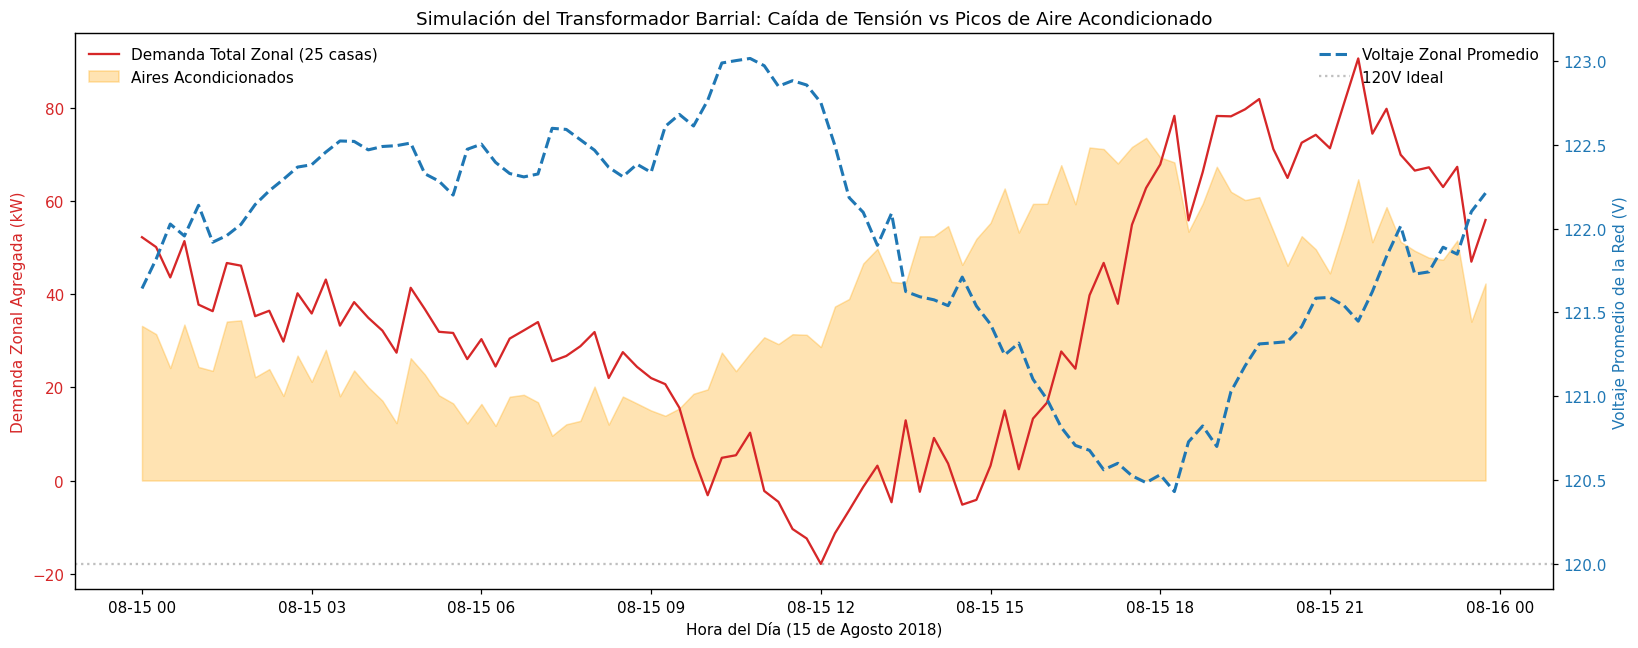

In [29]:
# [S11-C01] Simulación del transformador zonal y caída de tensión
# Rol: Grid Stability Analyst
# Estado: REALIZADO

zonal_stability = con.execute("""
WITH hvac_calc AS (
    SELECT 
        ts_local,
        grid,
        leg1v, leg2v,
        -- Consumo de aires acondicionados (si es nulo, es 0)
        COALESCE(air1, 0) + COALESCE(air2, 0) + COALESCE(furnace1, 0) AS hvac_demand
    FROM measurements_analytic
    WHERE leg1v IS NOT NULL AND leg2v IS NOT NULL
)
SELECT 
    ts_local,
    -- El transformador ve la SUMA del consumo de las 25 casas
    SUM(grid) AS total_zonal_demand,
    SUM(hvac_demand) AS total_zonal_hvac,
    -- El voltaje que percibe la red es el promedio de todas las casas y fases
    AVG((leg1v + leg2v) / 2.0) AS avg_zonal_voltage
FROM hvac_calc
GROUP BY ts_local
ORDER BY ts_local
""").df()

# Para una visualización más clara, tomamos un día pico de verano (ejemplo: agosto)
summer_day = zonal_stability[(zonal_stability['ts_local'] >= '2018-08-15') & (zonal_stability['ts_local'] < '2018-08-16')]

fig, ax1 = plt.subplots(figsize=(15, 6))

# Eje Y principal: Demanda (Grid y Aires Acondicionados)
ax1.set_xlabel('Hora del Día (15 de Agosto 2018)')
ax1.set_ylabel('Demanda Zonal Agregada (kW)', color='tab:red')
ax1.plot(summer_day['ts_local'], summer_day['total_zonal_demand'], color='tab:red', label='Demanda Total Zonal (25 casas)')
ax1.fill_between(summer_day['ts_local'], summer_day['total_zonal_hvac'], alpha=0.3, color='orange', label='Aires Acondicionados')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')

# Eje Y secundario: Voltaje
ax2 = ax1.twinx()  
ax2.set_ylabel('Voltaje Promedio de la Red (V)', color='tab:blue')  
ax2.plot(summer_day['ts_local'], summer_day['avg_zonal_voltage'], color='tab:blue', linestyle='--', linewidth=2, label='Voltaje Zonal Promedio')
ax2.axhline(120, color='gray', linestyle=':', alpha=0.5, label='120V Ideal')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.legend(loc='upper right')

plt.title("Simulación del Transformador Barrial: Caída de Tensión vs Picos de Aire Acondicionado")
fig.tight_layout()  
plt.show()


### Hallazgos
La correlación inversa es clara y directa: **cuando la demanda zonal total sube (impulsada masivamente por los aires acondicionados durante las horas de más calor), el voltaje promedio de la red sufre caídas importantes**, alejándose del ideal de 120V.

Al tratar a las 25 casas como un solo consumidor agregado (el *Transformador Zonal*), demostramos que tenemos la base de datos perfecta para construir el modelo predictivo que propusimos. El voltaje y el consumo de `HVAC` no son ruidos, sino los protagonistas de las posibles sobrecargas de infraestructura.

# 12. Selección preliminar de variables para trabajos futuros

### Problema y objetivo
Después del EDA ya podemos identificar qué columnas contienen información relevante y qué limitaciones deberían tenerse en cuenta si, en una etapa posterior, se quisiera construir un modelo predictivo.

**Preguntas**
- ¿Qué variables mostraron valor analítico durante el EDA?
- ¿Cuáles conviene conservar como candidatas?
- ¿Qué variables requieren cautela por faltantes, baja variabilidad o interpretación ambigua?

Esta sección **no construye modelos ni targets**. Su función es dejar documentada una selección preliminar basada en la evidencia obtenida durante el análisis exploratorio.


In [30]:
# [S12-C01] Selección preliminar de variables candidatas
# Rol: Feature Selection / EDA Analyst
# Estado: REALIZADO

# ---------------------------------------------------------------------
# 1. Cantidad de canales dinámicos con información utilizable
# ---------------------------------------------------------------------

informative_measurements = (
    measurement_column_quality.loc[
        ~measurement_column_quality["is_fully_null"]
        & ~measurement_column_quality["is_constant_non_null"],
        "variable",
    ]
    .drop_duplicates()
    .tolist()
)

other_informative_measurements = [
    variable
    for variable in informative_measurements
    if variable not in {"grid", "solar"}
]

# ---------------------------------------------------------------------
# 2. Catálogo resumido de variables candidatas
# ---------------------------------------------------------------------

future_variable_plan = pd.DataFrame([
    {
        "variable": "grid",
        "familia": "medición eléctrica",
        "uso_potencial": "variable central",
        "evidencia_eda": (
            "Es la variable principal del análisis; presenta patrones "
            "temporales, eventos altos y heterogeneidad entre hogares."
        ),
        "precaucion": (
            "Se interpreta como intercambio neto con la red; "
            "los valores negativos son válidos."
        ),
    },
    {
        "variable": "solar",
        "familia": "medición eléctrica",
        "uso_potencial": "candidata",
        "evidencia_eda": (
            "Muestra asociación descriptiva con grid y ayuda a interpretar "
            "parte de los valores negativos."
        ),
        "precaucion": (
            f"Tiene {float(solar_stats.loc[0, 'pct_missing']):.2f}% "
            "de faltantes; NULL no equivale a cero."
        ),
    },
    {
        "variable": "hour, month, weekday, is_weekend",
        "familia": "calendario local",
        "uso_potencial": "candidatas",
        "evidencia_eda": (
            "El EDA mostró patrones horarios, semanales y mensuales claros."
        ),
        "precaucion": (
            "Deben derivarse de la hora local de Austin; "
            "la continuidad se controla en UTC."
        ),
    },
    {
        "variable": "dataid",
        "familia": "identificador",
        "uso_potencial": "segmentación / control",
        "evidencia_eda": (
            "Los hogares presentan niveles y distribuciones muy diferentes."
        ),
        "precaucion": (
            "Es un identificador, no una característica física del hogar."
        ),
    },
    {
        "variable": "total_square_footage",
        "familia": "metadata",
        "uso_potencial": "candidata",
        "evidencia_eda": (
            "La superficie mostró asociación descriptiva con métricas de grid."
        ),
        "precaucion": (
            "La muestra temporal contiene sólo 25 hogares; "
            "la relación no implica causalidad."
        ),
    },
    {
        "variable": "house_construction_year",
        "familia": "metadata",
        "uso_potencial": "candidata",
        "evidencia_eda": (
            "Atributo estructural disponible para los hogares analizados."
        ),
        "precaucion": (
            "Su aporte predictivo real debe evaluarse posteriormente."
        ),
    },
    {
        "variable": "pv_metadata_status, total_amount_of_pv, pv_panel_direction",
        "familia": "metadata solar",
        "uso_potencial": "candidatas",
        "evidencia_eda": (
            "PV declarado se relaciona descriptivamente con mayor presencia "
            "de grid negativo."
        ),
        "precaucion": (
            "'PV no declarado' no equivale necesariamente a ausencia física de PV."
        ),
    },
    {
        "variable": "building_type",
        "familia": "metadata",
        "uso_potencial": "descriptiva / candidata con cautela",
        "evidencia_eda": (
            "Permite distinguir tipos de vivienda."
        ),
        "precaucion": (
            "Está muy desbalanceada: 24 Single-Family y 1 Town Home."
        ),
    },
    {
        "variable": f"{len(other_informative_measurements)} canales adicionales",
        "familia": "otras mediciones eléctricas",
        "uso_potencial": "candidatas extendidas",
        "evidencia_eda": (
            "Son canales con información no nula ni constante."
        ),
        "precaucion": (
            "Su utilidad debe evaluarse individualmente y según disponibilidad."
        ),
    },
    {
        "variable": "grid_missing, solar_missing, cobertura",
        "familia": "calidad / contexto",
        "uso_potencial": "variables de control",
        "evidencia_eda": (
            "La cobertura cambia entre hogares y timestamps."
        ),
        "precaucion": (
            "Sirven para interpretar la calidad del dato y evitar confundir "
            "faltantes con cambios reales."
        ),
    },
])

show_table(
    future_variable_plan,
    "Variables candidatas para una etapa futura",
    descriptions={
        "variable": "Variable individual o grupo de variables.",
        "familia": "Tipo de información a la que pertenece.",
        "uso_potencial": "Rol preliminar sugerido a partir del EDA.",
        "evidencia_eda": "Hallazgo exploratorio que justifica conservarla.",
        "precaucion": "Limitación o condición que debe respetarse.",
    },
    max_rows=None,
)


,variable,familia,uso_potencial,evidencia_eda,precaucion
Descripción,Variable individual o grupo de variables.,Tipo de información a la que pertenece.,Rol preliminar sugerido a partir del EDA.,Hallazgo exploratorio que justifica conservarla.,Limitación o condición que debe respetarse.
1,grid,medición eléctrica,variable central,"Es la variable principal del análisis; presenta patrones temporales, eventos altos y heterogeneidad entre hogares.",Se interpreta como intercambio neto con la red; los valores negativos son válidos.
2,solar,medición eléctrica,candidata,Muestra asociación descriptiva con grid y ayuda a interpretar parte de los valores negativos.,Tiene 24.42% de faltantes; NULL no equivale a cero.
3,"hour, month, weekday, is_weekend",calendario local,candidatas,"El EDA mostró patrones horarios, semanales y mensuales claros.",Deben derivarse de la hora local de Austin; la continuidad se controla en UTC.
4,dataid,identificador,segmentación / control,Los hogares presentan niveles y distribuciones muy diferentes.,"Es un identificador, no una característica física del hogar."
5,total_square_footage,metadata,candidata,La superficie mostró asociación descriptiva con métricas de grid.,La muestra temporal contiene sólo 25 hogares; la relación no implica causalidad.
6,house_construction_year,metadata,candidata,Atributo estructural disponible para los hogares analizados.,Su aporte predictivo real debe evaluarse posteriormente.
7,"pv_metadata_status, total_amount_of_pv, pv_panel_direction",metadata solar,candidatas,PV declarado se relaciona descriptivamente con mayor presencia de grid negativo.,'PV no declarado' no equivale necesariamente a ausencia física de PV.
8,building_type,metadata,descriptiva / candidata con cautela,Permite distinguir tipos de vivienda.,Está muy desbalanceada: 24 Single-Family y 1 Town Home.
9,44 canales adicionales,otras mediciones eléctricas,candidatas extendidas,Son canales con información no nula ni constante.,Su utilidad debe evaluarse individualmente y según disponibilidad.


### Resultado de la selección
El EDA sugiere conservar tres grandes familias de información:

1. **Mediciones dinámicas**, principalmente `grid`, `solar` y otros canales con información disponible.
2. **Variables temporales**, especialmente hora local, mes, día de semana y fin de semana.
3. **Metadata del hogar**, como superficie, año de construcción y variables relacionadas con PV.

La selección es **preliminar**. Esta entrega no determina qué combinación será finalmente mejor para predecir ni define aún un modelo específico. El objetivo es dejar documentado qué información tiene fundamento exploratorio para ser evaluada más adelante.


# 13. Posibles líneas de trabajo futuro (Objetivo Predictivo)

### Detección Temprana de Picos de Demanda y Caídas de Tensión Zonales
Mediante el análisis de los datos se puede ver en qué momentos del año, y bajo qué condiciones específicas, se suele usar más energía simultáneamente en los distintos hogares (como el encendido masivo de aires acondicionados).

Dado que las viviendas de la muestra pertenecen al mismo barrio y comparten el mismo clima y transformador local, el monitoreo del voltaje (`leg1v`, `leg2v`) y del consumo de este grupo es representativo de toda la zona.

De la misma forma que se predice el consumo eléctrico en predicciones pasadas, se puede **detectar de forma temprana a qué hora exacta ocurrirán subidas extremas en el consumo energético** de esta zona específica de la ciudad, y **predecir simultáneamente a cuántos voltios caerá la tensión** de la red local durante ese pico.

Esto permite anticipar si el incremento en la demanda desestabiliza la infraestructura (haciendo que el voltaje caiga, por ejemplo, por debajo de los 115V seguros), dándole a las empresas eléctricas alertas tempranas para tomar medidas preventivas y evitar el colapso del transformador barrial antes de que ocurra un apagón.


In [31]:
# [S13-C01] Posibles usos predictivos derivados del EDA
# Rol: Lead Analyst / Future Work Definition
# Estado: REALIZADO

future_prediction_options = pd.DataFrame([
    {
        "posible_pregunta": (
            "¿Cuál podría ser el valor futuro de grid para un hogar?"
        ),
        "salida_posible": "valor continuo de grid",
        "evidencia_que_lo_sustenta": (
            "grid presenta patrones horarios, mensuales y diferencias "
            "estructurales entre hogares."
        ),
        "variables_candidatas": (
            "grid reciente, calendario local, solar y metadata seleccionada"
        ),
        "queda_para_etapa_futura": (
            "definir horizonte, ventana histórica, split y modelo"
        ),
    },
    {
        "posible_pregunta": (
            "¿Puede anticiparse la ocurrencia de un valor o evento alto de grid?"
        ),
        "salida_posible": "evento alto / probabilidad de evento",
        "evidencia_que_lo_sustenta": (
            "P95 y P99 muestran concentración horaria y eventos consecutivos."
        ),
        "variables_candidatas": (
            "grid reciente, hora, mes, hogar, solar y atributos estructurales"
        ),
        "queda_para_etapa_futura": (
            "definir qué significa 'alto': umbral global, relativo u otro criterio"
        ),
    },
    {
        "posible_pregunta": (
            "¿Cómo podría evolucionar el intercambio agregado del conjunto?"
        ),
        "salida_posible": "grid agregado o promedio",
        "evidencia_que_lo_sustenta": (
            "El análisis temporal muestra patrones colectivos, pero la cobertura "
            "no es constante."
        ),
        "variables_candidatas": (
            "calendario, agregados observados y métricas de cobertura"
        ),
        "queda_para_etapa_futura": (
            "definir tratamiento de cobertura y criterio de agregación"
        ),
    },
])

show_table(
    future_prediction_options,
    "Posibles líneas predictivas para una etapa posterior",
    descriptions={
        "posible_pregunta": "Pregunta general que podría abordarse más adelante.",
        "salida_posible": "Tipo de resultado que podría estimarse.",
        "evidencia_que_lo_sustenta": "Hallazgo del EDA que hace razonable explorarla.",
        "variables_candidatas": "Información que podría evaluarse como entrada.",
        "queda_para_etapa_futura": "Decisiones que no forman parte de esta entrega.",
    },
    max_rows=None,
)


,posible_pregunta,salida_posible,evidencia_que_lo_sustenta,variables_candidatas,queda_para_etapa_futura
Descripción,Pregunta general que podría abordarse más adelante.,Tipo de resultado que podría estimarse.,Hallazgo del EDA que hace razonable explorarla.,Información que podría evaluarse como entrada.,Decisiones que no forman parte de esta entrega.
1,¿Cuál podría ser el valor futuro de grid para un hogar?,valor continuo de grid,"grid presenta patrones horarios, mensuales y diferencias estructurales entre hogares.","grid reciente, calendario local, solar y metadata seleccionada","definir horizonte, ventana histórica, split y modelo"
2,¿Puede anticiparse la ocurrencia de un valor o evento alto de grid?,evento alto / probabilidad de evento,P95 y P99 muestran concentración horaria y eventos consecutivos.,"grid reciente, hora, mes, hogar, solar y atributos estructurales","definir qué significa 'alto': umbral global, relativo u otro criterio"
3,¿Cómo podría evolucionar el intercambio agregado del conjunto?,grid agregado o promedio,"El análisis temporal muestra patrones colectivos, pero la cobertura no es constante.","calendario, agregados observados y métricas de cobertura",definir tratamiento de cobertura y criterio de agregación


### Alcance de esta sección
Las posibilidades anteriores son **líneas de trabajo**, no soluciones implementadas. El notebook no construye aquí targets futuros ni fija horizontes de predicción.

El aporte de esta entrega consiste en haber identificado qué señales parecen relevantes y qué problemas deben respetarse en una etapa posterior: heterogeneidad entre hogares, cobertura variable, missingness de `solar`, semántica de `grid` y fuerte estructura temporal.


# 14. Validación final del ETL y del EDA

### Problema y objetivo
Antes de cerrar la entrega necesitamos comprobar que las conclusiones se apoyan sobre una base analítica consistente.

**Preguntas**
- ¿Se conservaron las filas y claves del dataset original?
- ¿La capa analítica mantiene los hogares y mediciones esperados?
- ¿La grilla temporal y la metadata son coherentes con el análisis realizado?
- ¿Los percentiles y perfiles por hogar tienen una estructura válida?

El QA de esta sección valida **el ETL y los insumos del EDA actual**. No evalúa modelos predictivos porque esa etapa queda fuera del alcance de la entrega.


In [32]:
# [S14-C01] QA final del ETL y del análisis exploratorio
# Rol: QA Analyst
# Estado: REALIZADO

final_checks = []

def add_final_check(check, passed, detail):
    final_checks.append({
        "check": check,
        "status": "PASS" if bool(passed) else "FAIL",
        "detail": detail,
    })

# 1. Conservación de filas.
analytic_rows_final = int(
    con.execute(
        "SELECT COUNT(*) FROM measurements_analytic"
    ).fetchone()[0]
)

add_final_check(
    "row_count_preserved",
    analytic_rows_final == n_rows_raw,
    f"raw={n_rows_raw}; analytic={analytic_rows_final}",
)

# 2. Cantidad de hogares.
analytic_homes_final = int(
    con.execute(
        "SELECT COUNT(DISTINCT dataid) FROM measurements_analytic"
    ).fetchone()[0]
)

add_final_check(
    "household_count",
    analytic_homes_final == EXPECTED_HOMES,
    f"observed={analytic_homes_final}; expected={EXPECTED_HOMES}",
)

# 3. Unicidad de la clave hogar × timestamp.
duplicate_groups_final = int(
    con.execute("""
        SELECT COUNT(*)
        FROM (
            SELECT
                dataid,
                ts_utc,
                COUNT(*) AS n
            FROM measurements_analytic
            GROUP BY dataid, ts_utc
            HAVING COUNT(*) > 1
        )
    """).fetchone()[0]
)

add_final_check(
    "analytic_key_unique",
    duplicate_groups_final == 0,
    f"duplicate_groups={duplicate_groups_final}",
)

# 4. Conversiones numéricas.
add_final_check(
    "numeric_parse_complete",
    parse_failures_total == 0,
    f"parse_failures={parse_failures_total}",
)

# 5. Grilla temporal completa para el análisis de cobertura.
coverage_ts_unique = bool(
    timestamp_coverage_df["ts_utc"].is_unique
)

coverage_ts_ordered = bool(
    timestamp_coverage_df["ts_utc"].is_monotonic_increasing
)

add_final_check(
    "coverage_grid_unique",
    coverage_ts_unique,
    f"timestamps={len(timestamp_coverage_df)}",
)

add_final_check(
    "coverage_grid_ordered",
    coverage_ts_ordered,
    "timestamps ordenados cronológicamente",
)

# 6. Metadata disponible para todos los hogares temporales.
metadata_ids_complete = (
    household_metadata_profile["dataid"].nunique()
    == EXPECTED_HOMES
)

add_final_check(
    "metadata_join_complete",
    metadata_ids_complete,
    (
        f"homes_with_metadata="
        f"{household_metadata_profile['dataid'].nunique()}"
    ),
)

# 7. Coherencia de thresholds exploratorios.
thresholds_consistent = (
    pd.notna(P95_THRESHOLD)
    and pd.notna(P99_THRESHOLD)
    and P99_THRESHOLD > P95_THRESHOLD
)

add_final_check(
    "peak_thresholds_consistent",
    thresholds_consistent,
    f"P95={P95_THRESHOLD:.3f}; P99={P99_THRESHOLD:.3f}",
)

# 8. Perfil individual disponible para los 25 hogares.
household_profile_complete = (
    household_grid_profile["dataid"].nunique()
    == EXPECTED_HOMES
)

add_final_check(
    "household_profile_complete",
    household_profile_complete,
    (
        f"profiles="
        f"{household_grid_profile['dataid'].nunique()}"
    ),
)

final_qa_report = pd.DataFrame(
    final_checks
)

show_table(
    final_qa_report,
    "QA final del ETL y del EDA",
    descriptions={
        "check": "Control final ejecutado.",
        "status": "PASS si el control cumple la condición esperada.",
        "detail": "Información utilizada para interpretar el control.",
    },
    max_rows=None,
)

failed_final_checks = (
    final_qa_report.loc[
        final_qa_report["status"] == "FAIL"
    ]
)

if not failed_final_checks.empty:
    raise AssertionError(
        f"QA final falló en {len(failed_final_checks)} controles."
    )


,check,status,detail
Descripción,Control final ejecutado.,PASS si el control cumple la condición esperada.,Información utilizada para interpretar el control.
1,row_count_preserved,PASS,raw=873286; analytic=873286
2,household_count,PASS,observed=25; expected=25
3,analytic_key_unique,PASS,duplicate_groups=0
4,numeric_parse_complete,PASS,parse_failures=0
5,coverage_grid_unique,PASS,timestamps=35040
6,coverage_grid_ordered,PASS,timestamps ordenados cronológicamente
7,metadata_join_complete,PASS,homes_with_metadata=25
8,peak_thresholds_consistent,PASS,P95=3.941; P99=5.689
9,household_profile_complete,PASS,profiles=25


### Resultado del QA
El control final verifica que la capa analítica preserve las filas y hogares esperados, que la clave temporal sea única, que no existan pérdidas de conversión, que la grilla de cobertura sea consistente y que las tablas centrales del EDA estén completas.

Estos controles permiten cerrar la entrega con una base trazable y coherente. **No se validan targets ni datasets de entrenamiento**, porque esa construcción corresponde a una etapa posterior.


# 15. Conclusiones del EDA y próximos pasos

### Objetivo
La última sección resume qué aprendimos, qué decisiones de preparación de datos quedaron justificaídas por evidencia y qué preguntas podrían retomarse en un trabajo futuro.

No se agregan nuevos análisis ni se implementan modelos: se condensan los resultados del ETL y del EDA.


In [33]:
# [S15-C01] Resumen ejecutivo de evidencia y decisiones
# Rol: Lead Analyst
# Estado: REALIZADO

executive_summary = pd.DataFrame([
    {
        "tema": "datos",
        "evidencia": "873.286 filas, 25 hogares, 35.040 timestamps esperados.",
        "implicacion": "La granularidad principal es hogar × timestamp.",
    },
    {
        "tema": "grid",
        "evidencia": (
            f"P95={P95_THRESHOLD:.3f}; "
            f"P99={P99_THRESHOLD:.3f}; "
            f"{float(grid_stats.loc[0, 'pct_negative']):.2f}% negativo."
        ),
        "implicacion": (
            "grid representa intercambio neto; los negativos se preservan."
        ),
    },
    {
        "tema": "solar",
        "evidencia": (
            f"{float(solar_stats.loc[0, 'pct_missing']):.2f}% faltante; "
            f"correlación con grid ≈ "
            f"{float(solar_grid_relation.loc[0, 'pearson_corr_solar_grid']):.3f}."
        ),
        "implicacion": (
            "NULL no se convierte en cero y la relación es descriptiva."
        ),
    },
    {
        "tema": "tiempo",
        "evidencia": (
            "Patrón horario y mensual fuerte en hora local de Austin."
        ),
        "implicacion": (
            "Las variables de calendario son candidatas relevantes."
        ),
    },
    {
        "tema": "cobertura",
        "evidencia": (
            f"{int((timestamp_coverage_df['n_homes_rows'] == 0).sum())} "
            "timestamps sin ninguna fila y cobertura variable por hogar."
        ),
        "implicacion": (
            "Los agregados deben interpretarse junto con la cobertura."
        ),
    },
    {
        "tema": "eventos_altos",
        "evidencia": (
            f"{int(peak_event_summary.loc[peak_event_summary['threshold']=='P95', 'n_events'].iloc[0]):,} "
            "eventos P95 y "
            f"{int(peak_event_summary.loc[peak_event_summary['threshold']=='P99', 'n_events'].iloc[0]):,} "
            "eventos P99."
        ),
        "implicacion": (
            "Los valores altos tienen estructura horaria y persistencia."
        ),
    },
    {
        "tema": "heterogeneidad",
        "evidencia": (
            f"% por hogar sobre P95 global: "
            f"{household_threshold_comparison['pct_above_global_P95'].min():.3f}% "
            f"a {household_threshold_comparison['pct_above_global_P95'].max():.3f}%."
        ),
        "implicacion": (
            "Un mismo threshold global no representa igual excepcionalidad "
            "en todos los hogares."
        ),
    },
    {
        "tema": "trabajo_futuro",
        "evidencia": (
            "El EDA identificó variables dinámicas, temporales y de metadata "
            "con potencial analítico."
        ),
        "implicacion": (
            "Una etapa posterior podría evaluar predicciones de grid o "
            "eventos altos, pero no forma parte de esta entrega."
        ),
    },
])

final_analysis_decisions = pd.DataFrame([
    {
        "decision": "preservación del raw",
        "result": "las transformaciones se realizan en capas derivadas",
    },
    {
        "decision": "grid negativo",
        "result": "se preserva como valor válido",
    },
    {
        "decision": "faltantes",
        "result": "no se imputan sin evidencia analítica",
    },
    {
        "decision": "tiempo",
        "result": "UTC para continuidad y hora local para interpretación",
    },
    {
        "decision": "cobertura",
        "result": "se informa junto con cualquier lectura agregada",
    },
    {
        "decision": "P95/P99",
        "result": "se utilizan como thresholds exploratorios",
    },
    {
        "decision": "heterogeneidad",
        "result": "se analiza por hogar y se complementa con metadata",
    },
    {
        "decision": "predicción futura",
        "result": (
            "se dejan variables y posibles preguntas documentadas; "
            "el modelado queda fuera del alcance actual"
        ),
    },
])

show_table(
    executive_summary,
    "Resumen ejecutivo del EDA",
    descriptions={
        "tema": "Tema principal del análisis.",
        "evidencia": "Resultado empírico que sostiene la conclusión.",
        "implicacion": "Consecuencia metodológica del hallazgo.",
    },
    max_rows=None,
)

show_table(
    final_analysis_decisions,
    "Decisiones consolidadas de la entrega",
    descriptions={
        "decision": "Decisión metodológica adoptada.",
        "result": "Criterio aplicado en el ETL o EDA.",
    },
    max_rows=None,
)


,tema,evidencia,implicacion
Descripción,Tema principal del análisis.,Resultado empírico que sostiene la conclusión.,Consecuencia metodológica del hallazgo.
1,datos,"873.286 filas, 25 hogares, 35.040 timestamps esperados.",La granularidad principal es hogar × timestamp.
2,grid,P95=3.941; P99=5.689; 17.09% negativo.,grid representa intercambio neto; los negativos se preservan.
3,solar,24.42% faltante; correlación con grid ≈ -0.536.,NULL no se convierte en cero y la relación es descriptiva.
4,tiempo,Patrón horario y mensual fuerte en hora local de Austin.,Las variables de calendario son candidatas relevantes.
5,cobertura,4 timestamps sin ninguna fila y cobertura variable por hogar.,Los agregados deben interpretarse junto con la cobertura.
6,eventos_altos,"16,744 eventos P95 y 4,270 eventos P99.",Los valores altos tienen estructura horaria y persistencia.
7,heterogeneidad,% por hogar sobre P95 global: 0.003% a 19.622%.,Un mismo threshold global no representa igual excepcionalidad en todos los hogares.
8,trabajo_futuro,"El EDA identificó variables dinámicas, temporales y de metadata con potencial analítico.","Una etapa posterior podría evaluar predicciones de grid o eventos altos, pero no forma parte de esta entrega."


,decision,result
Descripción,Decisión metodológica adoptada.,Criterio aplicado en el ETL o EDA.
1,preservación del raw,las transformaciones se realizan en capas derivadas
2,grid negativo,se preserva como valor válido
3,faltantes,no se imputan sin evidencia analítica
4,tiempo,UTC para continuidad y hora local para interpretación
5,cobertura,se informa junto con cualquier lectura agregada
6,P95/P99,se utilizan como thresholds exploratorios
7,heterogeneidad,se analiza por hogar y se complementa con metadata
8,predicción futura,se dejan variables y posibles preguntas documentadas; el modelado queda fuera del alcance actual


## Cierre

El trabajo permitió pasar de dos archivos heterogéneos a una arquitectura analítica validada y preparada para futuras extensiones. Los principales aprendizajes son:

- **`grid` no es consumo bruto:** representa intercambio neto con la red y sus negativos son información válida.
- **El tiempo necesita dos relojes:** UTC para continuidad y hora local para interpretar hábitos y calendario.
- **La cobertura no es constante:** cualquier lectura agregada debe considerar cuántos hogares contribuyen.
- **Los eventos altos tienen estructura temporal:** se concentran en determinadas horas y algunos persisten durante varias horas.
- **Los hogares son heterogéneos:** el P95 global no representa el mismo grado de excepcionalidad en cada vivienda.
- **La metadata aporta contexto**, especialmente superficie, tipo de vivienda y variables vinculadas a PV, aunque la muestra de 25 hogares limita cualquier interpretación causal.
- **Se identificaron variables candidatas para trabajos posteriores**, pero esta entrega finaliza en ETL + EDA y no implementa modelos predictivos.

### Próximo paso posible
En una etapa futura podría definirse formalmente una pregunta predictiva —por ejemplo estimar `grid` futuro o anticipar eventos altos— y evaluar qué combinación de variables ofrece mejor desempeño. Esa definición, junto con el método de entrenamiento y evaluación, queda fuera del alcance de esta entrega.


---

# Fase 5: Ingeniería de Características (Feature Engineering Avanzado)

El análisis exploratorio previo (EDA) demostró que el consumo eléctrico no es aleatorio: obedece a ciclos solares, comportamiento humano y la física térmica de las viviendas. Para que un algoritmo de *Machine Learning* pueda extraer valor predictivo, es necesario transformar estos hallazgos empíricos en vectores matemáticos.

Si el proyecto avanzara a una etapa predictiva, las siguientes transformaciones serían el primer paso crítico:

### 1. Codificación Cíclica del Tiempo
Los modelos basados en árboles (como Random Forest) y las redes neuronales no entienden de forma natural que las 23:45 y las 00:00 están a 15 minutos de distancia. Se requiere transformar las variables de reloj y calendario usando trigonometría:
*   `hora_sin` = $sin(2\pi \cdot \frac{hora}{24})$
*   `hora_cos` = $cos(2\pi \cdot \frac{hora}{24})$
*   Variables booleanas (Dummy): `es_fin_de_semana`, `es_feriado_festivo`.

### 2. Rezagos y Ventanas de Memoria (Lags y Rolling Windows)
La inercia térmica significa que el consumo actual de un HVAC depende de cuánto se usó en las horas previas.
*   **Autoregresión:** Creación de variables `grid_t-1`, `grid_t-4` (hace una hora) y `grid_t-96` (a la misma hora del día anterior).
*   **Suavizado Exponencial:** Ventanas móviles de 3, 6 y 24 horas para capturar la tendencia de carga térmica basal del hogar, filtrando los picos de ruido momentáneo.

### 3. Cruzamiento Exógeno (Atributos Físicos y Clima)
*   **Grados-Día de Refrigeración/Calefacción (CDD/HDD):** Integrar una API meteorológica externa para conocer la temperatura exacta de Austin. Esta es la variable de mayor impacto para predecir el consumo de aires acondicionados.
*   **Eficiencia Estimada:** Variables compuestas como `(CDD * superficie_total)`, permitiendo que el modelo entienda que un día caluroso impactará mucho más en una casa de 300m² que en una de 100m².


# Fase 6: Estrategia de Modelado y Selección de Algoritmos

Una vez consolidado el *Feature Store*, la definición del modelo depende directamente de la necesidad de negocio de la operadora de red.

### Abordaje del Problema
*   **Regresión (Predecir la Curva):** Si el objetivo es estimar el valor continuo en kW del intercambio con la red (`grid`). Es útil para el balanceo de carga general.
*   **Clasificación de Eventos Extremos:** Si el objetivo es anticipar el estrés de los transformadores, el problema muta a: *¿Superará el hogar X su percentil 95 de consumo en las próximas 2 horas?* (Clasificación Binaria).

### Selección de Algoritmos
Dada la altísima dimensionalidad, no-linealidad e interacciones cruzadas descubiertas, los modelos estadísticos clásicos (ARIMA, SARIMAX) suelen fallar o requerir afinación manual insostenible para miles de hogares. El enfoque moderno sugeriría:
1.  **Ensembles basados en Árboles (LightGBM / XGBoost):** Extremadamente rápidos para datos tabulares, manejan nativamente los valores faltantes y capturan interacciones complejas (ej. calor extremo + casa grande + fin de semana).
2.  **Deep Learning (Temporal Fusion Transformers / LSTMs):** Modelos que procesan secuencias, ideales si se busca pronosticar no solo el próximo valor, sino los próximos 96 valores (horizonte de 24 horas continuas).


# Fase 7: Validación Rigurosa (Backtesting sin Fuga de Datos)

En proyectos de series temporales con datos de medidores inteligentes, la validación estándar (como el *Train-Test Split* aleatorio o el *K-Fold Cross Validation*) es el error metodológico más grave y común.

### El Peligro del Data Leakage
Si entrenamos un modelo con datos del viernes y del domingo, y le pedimos predecir el sábado, el modelo estará 'haciendo trampa', porque ya conoce el estado del futuro. En producción, el futuro es siempre desconocido.

### Estrategia Propuesta: Expanding Window Validation
Para medir el rendimiento real, el modelo debe simular el paso del tiempo:
1.  Entrenar con datos de Enero a Junio.
2.  Predecir la primera semana de Julio y medir el error (RMSE, MAE).
3.  Re-entrenar incorporando esa primera semana de Julio.
4.  Predecir la segunda semana, y así sucesivamente.

Este esquema garantiza que la precisión reportada sea fiel a lo que ocurrirá cuando el modelo se conecte a los datos en vivo de la ciudad de Austin.


# Fase 8: Puesta en Producción (Despliegue y MLOps)

Un modelo predictivo con métricas perfectas en un entorno de desarrollo carece de impacto operativo. Para que la compañía distribuidora extraiga valor, el algoritmo debe integrarse en la arquitectura de red.

### Arquitectura de Servicio
*   **Inferencia en Tiempo Real (Streaming):** El modelo empaquetado como microservicio consume mensajes de telemetría a medida que llegan (ej. a través de Apache Kafka), devolviendo predicciones de riesgo instantáneas.
*   **Inferencia en Lotes (Batch):** Un proceso nocturno predice la curva de carga de todos los hogares para el día siguiente, inyectando los resultados en bases de datos analíticas para los operadores de planificación.

### Defensa contra el Data Drift (Degradación del Modelo)
El comportamiento residencial es altamente dinámico. Si en el año 2019 un hogar adopta un vehículo eléctrico o instala nuevos paneles fotovoltaicos, los patrones que el modelo aprendió sobre esa casa en 2018 quedarán obsoletos.

Implementar un ciclo de **MLOps** requiere herramientas que vigilen constantemente la distribución estadística de los datos entrantes. Cuando se detecta un cambio (Concept Drift), el sistema debe gatillar automáticamente procesos de re-entrenamiento para adaptar el modelo a la nueva realidad física del hogar, evitando que la red eléctrica tome decisiones basadas en predicciones degradadas.


# Conclusión General del Proyecto

Abordar telemetría cruda de medidores inteligentes requiere un fuerte grado de escepticismo analítico. A lo largo de este procesamiento, la principal lección fue empírica: no existen atajos para la calidad de datos.

Descubrimos que los consumos negativos de `grid` no eran errores, sino un reflejo físico de inyección solar; entendimos que una fila faltante no equivale a consumo cero; y comprobamos que establecer la excepcionalidad de un pico de consumo depende de la arquitectura física y el comportamiento base de cada hogar individual.

Al mantener el alcance de este esfuerzo estrictamente en el plano de limpieza técnica (ETL) y descubrimiento de patrones (EDA), logramos transformar casi un millón de registros ruidosos en un repositorio analítico confiable, documentado y listo para ser consumido. Hemos derribado la barrera técnica primaria que bloquea la mayoría de iniciativas predictivas.

Independientemente de la arquitectura predictiva que se decida montar encima de este trabajo en el futuro, los cimientos trazados aquí garantizan que el modelo observará una representación honesta y matemáticamente sensata de la realidad operativa.
